# 02 · Veri Ön İşleme: Eksik Veri, Aykırı Değer, Encoding ve Ölçekleme (Data Preprocessing)
**Classical ML Lab** · Modele Girmeden Önce Veriyi Modele Hazır Hale Getirmek

---
> **Bu notebook'ta ne öğreneceğiz?**
> Hiçbir gerçek veri seti "temiz" gelmez: sütunlar eksik, aykırı değerler var, kategorik sütunlar sayısal modele girmiyor, ölçekler birbirinden kopuk (biri 0-1 arası oran, diğeri yüz binlerle ifade edilen fiyat). `eda_visualization.ipynb`'de (Classical ML Lab 01) bu sorunları **görsel olarak fark etmeyi** öğrendik — bu notebook'ta onları **sistematik olarak çözmeyi** öğreniyoruz. Kapsam:
>
> - **Eksik Veri:** Eksiklik mekanizmaları (MCAR/MAR/MNAR), Mean/Median/Mode Imputation, KNN Imputation, Iterative Imputer (MICE), eksiklik göstergesi (missing indicator)
> - **Aykırı Değer Tespiti:** IQR (Tukey) kuralı, Z-Score, Modified Z-Score (MAD), winsorizing/capping
> - **Kategorik Encoding:** One-Hot, Label, Ordinal, Target (Mean) Encoding + smoothing, Frequency Encoding
> - **Ölçekleme:** Standardization, Min-Max Normalization, Robust Scaling, Log/Power Transform
> - **Temel Özellik Mühendisliği:** türetilmiş/oran özellikler, binning, etkileşim/polinom özellikler, tarih ayrıştırma
>
> Bunları **3 farklı, gerçek ve iyi bilinen veri seti** üzerinde — her birini güçlü olduğu senaryoda kullanarak — Python (pandas/scikit-learn), R (tidyverse/mice/recipes) ve SQL (DuckDB) ile uygulayacağız. Son adımda hepsini gerçek bir `Pipeline` + `ColumnTransformer` içinde birleştireceğiz — bu, iş hayatında üretim koduna en yakın adım.

**Önkoşul:** EDA Görselleştirme (Classical ML Lab 01) — burada aykırı değer/dağılım şeklini boxplot, histogram ve ECDF ile *görmeyi* öğrendik, şimdi onlarla *ne yapacağımızı* öğreniyoruz.
**Veriler (üçü de iyi bilinen, güvenilir akademik/Kaggle kaynaklı veri setleri):**
- 🏠 **Ames Housing** — [jse.amstat.org/v19n3/decock](https://jse.amstat.org/v19n3/decock/DataDocumentation.txt) (De Cock, 2011, *Journal of Statistics Education*) / [kaggle.com/competitions/house-prices-advanced-regression-techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques) — 2.930 satır, 82 sütun; gerçek, çeşitli eksik veri örüntüleri (rastgele + yapısal/MNAR), yüksek kardiniteli kategorik sütunlar (28 mahalle), sıralı kalite skalaları — bu notebook'un omurgası
- 🩺 **Pima Indians Diabetes** — [UCI ML Repository](https://archive.ics.uci.edu/dataset/34/diabetes) / [kaggle.com/datasets/uciml/pima-indians-diabetes-database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database) — 768 satır; **gizlenmiş eksik veri** klasiği (fizyolojik olarak imkansız `0` değerleri aslında `NaN`), imputation yöntemlerini karşılaştırmak için ideal
- 🍷 **Red Wine Quality** — [Cortez et al., 2009, *Decision Support Systems*](https://www.sciencedirect.com/science/article/abs/pii/S0167923609001377) / [kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009) — 1.599 satır, tamamı sayısal, eksik değer yok — ölçekleme ve aykırı değer yöntemlerini saf haliyle karşılaştırmak için ideal

**Araçlar:** Python (pandas, scikit-learn), R (tidyverse, mice, recipes, VIM), SQL (DuckDB)


---
## 1 · Neden Veri Ön İşleme? "Garbage In, Garbage Out"

Bir modelin ne kadar sofistike olduğu önemli değil — girdisi bozuksa çıktısı da bozuk olur. Dört somut sorun:

1. **Eksik veri:** Çoğu scikit-learn modeli (ağaç tabanlılar hariç bazı yeni sürümler) `NaN` gördüğünde hata verir. Basitçe satırı silmek, veri kaybına ve (eksiklik rastgele değilse) **yanlılığa (bias)** yol açabilir.
2. **Aykırı değerler:** Ortalama, standart sapma, korelasyon gibi pek çok istatistik aykırı değerlere karşı **dayanıksızdır (non-robust)** — tek bir aşırı değer bütün bir doğrusal regresyon katsayısını kaydırabilir.
3. **Kategorik veri:** `"Excellent"`, `"Good"`, `"Fair"` gibi metin değerlerini hiçbir matematiksel model doğrudan işleyemez — sayıya çevrilmeleri gerekir, ama *nasıl* çevrildiği (sıralı mı, sırasız mı) sonucu doğrudan etkiler.
4. **Farklı ölçekler:** `Lot_Area` (binlerce $m^2$) ile `Overall_Qual` (1-10 arası) aynı modele girdiğinde, mesafe/gradyan tabanlı algoritmalar (KNN, SVM, lojistik regresyon, sinir ağları, K-Means) büyük ölçekli değişkeni "daha önemli" sanır — oysa bu sadece birim farkıdır.

**Altın kural:** Ön işleme adımları (imputer, encoder, scaler) **sadece eğitim (train) verisiyle `fit` edilmeli**, sonra hem train hem test'e `transform` uygulanmalıdır. Aksi halde test setinden train'e bilgi sızar (**data leakage**) ve model gerçek performansından daha iyi görünür. Bu notebook'ta tek tek gösterdiğimiz adımları, son bölümde tam da bu kurala uyan bir `Pipeline` içinde birleştireceğiz.


---
## 2 · Veri Ön İşleme Karar Haritası

Aşağıdaki dört alt bölüm, sırasıyla **eksik veri, aykırı değer, encoding ve ölçekleme** için "hangi durumda hangi yöntem" sorusuna somut, sayısal eşiklerle cevap veriyor — her biri dört aynı eksene bakıyor: **eksiklik/aykırılık oranı**, **dağılımın şekli (çarpıklık)**, **kullanılacak model tipi**, ve **endüstride gerçekte ne yapılıyor**. Bölüm 3-7'deki teoriyi okurken bu haritaya geri dönüp "ben şimdi hangi dalı izliyorum?" diye sorman, doğru yöntemi seçmeni kolaylaştıracak.

### 2.1 Eksik Veri — Karar Akışı

**Adım 1 — Önce sor: Bu eksiklik yapısal mı (MNAR), yoksa gerçekten "bilinmiyor" mu?**
Domain bilgisiyle kontrol et: sütun boşken aslında "bu özellik yok" mu demek istiyor (örn. `Pool_QC` boşsa evde havuz yoktur)? **Evetse** hiçbir imputation yöntemi kullanma — doğrudan `"None"`/`0` ile doldur + bir eksiklik göstergesi (`Has_X`) ekle (Bölüm 3.6, Python 4). Bu adımı atlayıp doğrudan mean/median doldurmak, en sık yapılan hatadır.

**Adım 2 — Yapısal değilse, eksiklik ORANINA göre karar ver:**

| Eksiklik Oranı | Önerilen Yöntem | Neden |
|---|---|---|
| **< %5** | Mean/Median (sayısal, çarpıklığa göre seç) veya Mode (kategorik); MCAR ise satırı silmek (listwise deletion) bile kabul edilebilir | Veri kaybı/varyans daralması ihmal edilebilir düzeyde kalır |
| **%5 – %15** | Önce diğer değişkenlerle korelasyona bak (`df.corr()`): güçlü ilişki (\|r\| > 0.3-0.4) varsa **KNN Imputation**; zayıfsa basit yöntem + eksiklik göstergesi | KNN, sadece ilişkili değişken varken basit yöntemden daha isabetli olur — ilişki yoksa fazladan karmaşıklık kazandırmaz |
| **%15 – %40** | **MICE / Iterative Imputer** + mutlaka eksiklik göstergesi | Bu aralıkta basit yöntemlerin varyans daralması (Bölüm 3.3) ciddi bir sorun hâline gelir; MICE çok değişkenli ilişkiyi korur |
| **> %40** | Önce "bu sütunu tamamen çıkarmalı mıyım?" sorusunu ciddiye al; kritikse MICE + gösterge dene, etkisini cross-validation ile ölç | Bu düzeyde her yöntem büyük ölçüde varsayım/gürültü üretir — kör güvenme |

**Adım 3 — Sayısal mı, kategorik mi?** Sayısalsa **çarpıklığa bak** (Bölüm 2.2'deki eşik aynı geçerli): simetrikse mean, çarpıksa median. Kategorikse her zaman mode (ya da yeterince veri varsa KNN/MICE de kategorik değişkenlerle çalışabilir, VIM::kNN ve `mice` bunu destekler).

**Endüstri notu:** Kaggle yarışmalarında ve üretim pipeline'larında varsayılan neredeyse her zaman `SimpleImputer(strategy='median')`'dır — hızlı, deterministik, "yeterince iyi". KNN/MICE, skorun ince farklarının önemli olduğu durumlarda (yarışma, kritik iş kararı) ekstra performans için sonradan denenir.

### 2.2 Aykırı Değer — Karar Akışı

**Adım 1 — Dağılımın şeklini ölç** (`scipy.stats.skew()` veya histogram/Q-Q plot):

| Çarpıklık (\|skewness\|) | Önerilen Tespit Yöntemi | Neden |
|---|---|---|
| **< 0.5** (yaklaşık simetrik/Normal) | **Z-Score** ($\lvert z\rvert>3$) | Normal dağılım varsayımı makul, klasik istatistik burada güvenilir |
| **0.5 – 1** (orta çarpık) | **Modified Z-Score** (MAD tabanlı) | Klasik z-score'un ortalama/std'si bu düzeyde çarpıklıktan etkilenmeye başlar |
| **≥ 1** (yüksek çarpık) veya **n < 30** | **IQR (1.5×) Kuralı** | Dağılım şekli hakkında hiçbir varsayım yapmaz (distribution-free), küçük örneklemde de güvenli |

**Adım 2 — Kaynağını sorgula:** Veri girişi hatası mı (örn. yaş = 200), yoksa gerçek ama nadir bir gözlem mi (örn. milyoner müşteri, rekor satış)? Hataysa düzelt/sil; gerçekse **asla silme** — o senin popülasyonunun gerçek bir parçası, silersen varyansı yapay olarak daraltırsın.

**Adım 3 — Modele göre ne yapılacağına karar ver:**
- **Ağaç tabanlı model** (Random Forest, XGBoost, LightGBM): aykırı değerlere doğal dayanıklı → genelde **hiçbir şey yapma**.
- **Mesafe/gradyan tabanlı model** (KNN, SVM, lineer/lojistik regresyon, sinir ağı): winsorizing/capping veya log/power transform uygula — aksi halde tek bir aykırı değer modeli domine edebilir.

**Endüstri notu:** Fraud detection / risk modelleme gibi "asıl ilgi alanı uç değerler olan" senaryolarda aykırı değerler **asla silinmez** — ayrı bir sinyal olarak doğrudan modellenir (bkz. Anomaly Detection, roadmap #18). Bu, "aykırı değer = hata" varsayımının her zaman doğru olmadığının en net örneğidir.

### 2.3 Kategorik Encoding — Karar Akışı

**Adım 1 — Sıralı mı (ordinal), sırasız mı (nominal)?** Doğal bir sıra varsa (kalite skalası, eğitim seviyesi, memnuniyet puanı) → **her zaman Ordinal Encoding**, kullanılan model ne olursa olsun bu değişmez.

**Adım 2 — Sırasızsa, kardinaliteye (kategori sayısına) bak:**

| Kardinalite | Önerilen Yöntem | Model Tipine Göre Not |
|---|---|---|
| **Düşük (< ~15 kategori)** | **One-Hot Encoding** | Hemen her model tipi için güvenli varsayılan |
| **Orta (~15 – 50 kategori)** | Ağaç tabanlıysa **Target/Frequency Encoding** (LightGBM/CatBoost bunu yerleşik de destekler); lineer/mesafe tabanlıysa One-Hot + boyut azaltma ya da düzenlileştirilmiş (regularized/smoothed) Target Encoding | One-Hot burada boyutu ciddi büyütmeye başlar |
| **Yüksek (> ~50 kategori,** örn. posta kodu, ürün ID) | **Target/Frequency Encoding, hashing trick**, ya da (derin öğrenmede) **embedding** | One-Hot **kesinlikle kullanılmamalı** — boyut patlar (curse of dimensionality) |

**Adım 3 — Label Encoding ne zaman kullanılır?** **Sadece** ağaç tabanlı modellerde, sırasız bir değişkeni hızlıca sayıya çevirmek için pratik bir "hack" olarak (ağaç sahte sırayı önemsemez) — **asla** lineer/mesafe tabanlı bir modelde nominal veri için kullanılmaz (Bölüm 5.2, Python 12'deki tuzağı hatırla).

**Endüstri notu:** Büyük ölçekli reklam/öneri sistemlerinde (kullanıcı ID, ürün ID gibi çok yüksek kardinaliteli değişkenler) One-Hot pratikte hiç kullanılmaz — üretimde neredeyse her zaman embedding katmanları tercih edilir.

### 2.4 Ölçekleme — Karar Akışı

**Adım 1 — Model ağaç tabanlı mı?** (Decision Tree, Random Forest, Gradient Boosting/XGBoost/LightGBM/CatBoost) → **Ölçekleme gerekmez**, bu adımı tamamen atla (Bölüm 6.5).

**Adım 2 — Değilse (mesafe/gradyan tabanlı: KNN, SVM, lineer/lojistik regresyon, sinir ağı, PCA, K-Means), aykırı değer durumuna bak:**

| Durum | Önerilen Scaler | Neden |
|---|---|---|
| Aykırı değer **yok / az** | **StandardScaler** | En yaygın kullanılan varsayılan, çoğu algoritmanın optimize edildiği ölçek |
| Aykırı değer **belirgin şekilde var** (Bölüm 2.2'deki tespite bak) | **RobustScaler** | Medyan/IQR kullanır, merkez aykırı değerlerden etkilenmez |
| Kesin bir $[0,1]$ aralığı gerekiyor (bazı sinir ağı girişleri, görüntü verisi) | **MinMaxScaler** — ama önce aykırı değerleri ele al | Aykırı değerlere en hassas scaler; tek bir uç nokta aralığı domine edebilir |

**Adım 3 — Dağılım çok çarpık mı (fiyat, gelir, sayım verisi)?** Ölçeklemeden **önce** log/power transform uygula (Bölüm 6.4), **sonra** seçtiğin scaler'ı uygula — sıralama önemli, tersi işe yaramaz.

**Endüstri notu:** Üretim ML pipeline'larında (bir sklearn `Pipeline` içinde) varsayılan neredeyse her zaman `StandardScaler`'dır; `RobustScaler`'a yalnızca aykırı değer tespiti sonrasında bilinçli olarak geçilir; `MinMaxScaler` çoğunlukla derin öğrenme/görüntü işleme bağlamında görülür.

### 2.5 Hızlı Referans Tablosu

Yukarıdaki dört karar akışının özet hâli — detaylı eşikler için ilgili alt bölüme geri dön:

| Problem | Yöntem | Ne Zaman? | Dikkat Edilmesi Gereken |
|---|---|---|---|
| Eksik veri (< %5, rastgele) | Mean / Median Imputation | MCAR/MAR, düşük eksiklik oranı | Varyansı azaltır, değişkenler arası ilişkiyi zayıflatır |
| Eksik veri (%5-15, ilişkili değişkenler) | KNN Imputation | Değişkenler arasında güçlü korelasyon var | Mesafe tabanlı olduğu için önce ölçekleme şart, büyük veride yavaş |
| Eksik veri (%15-40, çok değişkenli) | Iterative Imputer / MICE | Birden çok sütun karşılıklı ilişkili | Hesaplama maliyetli, yakınsama takibi gerekir |
| Eksik veri (yapısal / MNAR) | `"None"` + Eksiklik Göstergesi | Eksiklik kendisi bilgi taşıyor (örn. "havuz yok") | Yanlış mekanizma varsayımı (MCAR sanıp silmek) ciddi yanlılık yaratır |
| Aykırı değer (\|skew\|≥1, genel amaçlı) | IQR (1,5×) Kuralı | Dağılım şekli bilinmiyor veya çok çarpık | Yaklaşık Normal veride bile makul, ama agresif olabilir |
| Aykırı değer (\|skew\|<0.5, Normal'e yakın) | Z-Score ($\lvert z\rvert>3$) | Dağılım Normal'e yakın | Ortalama/std'nin kendisi aykırı değerlerden etkilenir |
| Aykırı değer (0.5≤\|skew\|<1, sağlam/robust) | Modified Z-Score (MAD) | Orta çarpık dağılım | Normal veri için z-score kadar yaygın tanınmaz |
| Kategorik (sıralı) | Ordinal Encoding | Doğal bir sıra var (örn. kalite skalası) | Yanlış sıra varsayımı ciddi hata yaratır |
| Kategorik (sırasız, < ~15 kategori) | One-Hot Encoding | Nominal, düşük kardinalite | Kategori arttıkça boyut patlar (curse of dimensionality) |
| Kategorik (sırasız, > ~15-20 kategori) | Target / Frequency Encoding | Çok sayıda kategori | Target encoding **leakage** riski taşır — CV/smoothing şart |
| Ölçekleme (mesafe/gradyan tabanlı, aykırı değer yok) | StandardScaler | KNN, SVM, lojistik regresyon, sinir ağı, PCA | Aykırı değerlere hassastır |
| Ölçekleme (mesafe/gradyan tabanlı, aykırı değer var) | RobustScaler | Aykırı değer içeren sayısal veri | Uç değerler hâlâ orijinal ölçekte kalır, sadece merkez sağlamlaşır |
| Ölçekleme ($[0,1]$ zorunluluğu) | MinMaxScaler | Sinir ağı girişleri | Aykırı değerlere **çok** hassastır |
| Ölçekleme/Dönüşüm (çarpık dağılım) | Log / Power Transform | Sağa çarpık, pozitif veri (fiyat, gelir, sayım) | Sıfır/negatif değerlerde `log1p` veya Yeo-Johnson gerekir; scaler'dan ÖNCE uygulanır |
| Ağaç tabanlı modeller (RF, GBM, XGBoost) | *Ölçekleme gerekmez* | Bölme noktaları sıraya bakar, mesafeye değil | Gereksiz bir adımı atlamak da bir karardır |



---
## 3 · Teori — Eksik Veri (Missing Data)

### 3.1 Eksiklik Mekanizmaları (Rubin, 1976)
Bir değeri doldurmadan önce sorulması gereken ilk soru: **neden eksik?** Donald Rubin'in 1976'da tanımladığı üç mekanizma:

- **MCAR (Missing Completely At Random):** Eksik olma olasılığı, gözlenen ya da gözlenmeyen hiçbir değişkenle ilişkili değil — tamamen şans eseri (örn. bir anket formunun rastgele bir kısmının kaybolması).
- **MAR (Missing At Random):** Eksik olma olasılığı, veri setindeki **gözlenen diğer** değişkenlerle ilişkili, ama eksik olan değerin kendisiyle değil (örn. yaşlı katılımcılar bir soruyu daha sık atlıyor — "yaş" gözlenen bir değişken).
- **MNAR (Missing Not At Random):** Eksik olma olasılığı, tam olarak **eksik olan değerin kendisiyle** ilişkili (örn. yüksek gelirli kişiler geliri bildirmemeyi tercih ediyor; havuzu olmayan bir evde "havuz kalitesi" sütunu doğal olarak boş).

**Pratik not:** MAR ile MNAR'ı veriden ayırt etmek genelde **imkansızdır** — çünkü eksik değerin kendisini gözlemleyemiyoruz. Bu yüzden analist, alan bilgisiyle (domain knowledge) bir varsayım yapmak zorundadır (Bölüm 3.6'daki Ames örneğinde olduğu gibi).

### 3.2 Listwise / Pairwise Deletion
En basit yöntem: eksik değeri olan satırı (`dropna()`) ya da sadece o hesaplamada kullanılan sütun çiftini silmek. MCAR altında yanlı değildir ama **veri kaybı** demektir; MAR/MNAR altında ise sistematik bir alt grubu dışarıda bırakarak **yanlılık (bias)** yaratabilir.

### 3.3 Basit İstatistiksel Imputation: Mean / Median / Mode
$$\hat x_{\text{eksik}} = \begin{cases}\text{mean}(x_{\text{gözlenen}}) & \text{simetrik dağılım}\\ \text{median}(x_{\text{gözlenen}}) & \text{çarpık dağılım / aykırı değer var}\\ \text{mode}(x_{\text{gözlenen}}) & \text{kategorik değişken}\end{cases}$$

Hızlı ve basittir, ama iki ciddi maliyeti vardır: **(1)** doldurulan değerler hep aynı sabit olduğu için değişkenin **varyansını yapay olarak azaltır**, **(2)** diğer değişkenlerle olan **korelasyonu zayıflatır** (çünkü imputed değer, o satırın diğer özelliklerinden bağımsız seçilir).

### 3.4 KNN Imputation
$$\hat{x}_{ij} = \frac{1}{k}\sum_{n \,\in\, N_k(i)} x_{nj}$$

Fikir: eksik değeri, **diğer (gözlenen) özelliklerde** en yakın $k$ komşunun ortalamasıyla (kategorikte modasıyla) doldurmak. Mean/median'in aksine, satırın geri kalanındaki bilgiyi kullanır. Mesafe ölçümü (genelde Öklid) ölçekten etkilendiği için, **KNN imputation'dan önce sayısal sütunları ölçeklemek şarttır** (Bölüm 6).

### 3.5 Iterative Imputer / MICE (Multiple Imputation by Chained Equations)
Van Buuren & Groothuis-Oudshoorn (2011, *Journal of Statistical Software* — R'daki `mice` paketinin de kaynağı olan makale) tarafından tanımlanan yöntem: eksik değeri olan her sütun, sırayla, **diğer tüm sütunları kullanan bir regresyon modeliyle** tahmin edilir; bu, tüm sütunlar için birkaç tur (iteration) tekrarlanarak sonuçlar yakınsayana kadar sürdürülür (chained equations). En güçlü ama en pahalı yöntemdir — mean/median'in aksine değişkenler arası **çok değişkenli ilişkiyi** korur, KNN'nin aksine **doğrusal/doğrusal olmayan bir model** üzerinden tahmin yapar.

### 3.6 Eksiklik Göstergesi (Missing Indicator) ve Yapısal Eksiklik
Bazı `NaN` değerleri istatistiksel bir eksiklik değil, **anlamlı bir "yok" bilgisidir** — örn. Ames veri setinde `Pool_QC` (havuz kalitesi) sütunundaki `NaN`, "bu evde havuz yok" demektir; rastgele/MAR bir eksiklik değil, **yapısal (structural) MNAR**'dır. Bu tür sütunlarda doğru işlem imputation değil, **`"None"` / `0` ile açıkça doldurmak**tır. Ayrıca, hangi yöntem kullanılırsa kullanılsın, bir `_missing` gösterge sütunu (0/1) eklemek, modele "bu değer gerçek mi imputed mi" bilgisini ayrıca taşıyabilir — bazı durumlarda eksikliğin *kendisi* öngörücü bir sinyaldir.


---
## 4 · Teori — Aykırı Değer Tespiti (Outlier Detection)

### 4.1 IQR (Interquartile Range) Kuralı — Tukey (1977)
$$IQR = Q_3 - Q_1 \qquad \text{Alt sınır} = Q_1 - 1.5\times IQR \qquad \text{Üst sınır} = Q_3 + 1.5\times IQR$$

`eda_visualization.ipynb`'deki boxplot'ların (Bölüm 3.5) matematiksel temeli tam olarak budur. Dağılım şekli hakkında bir varsayım yapmaz (**distribution-free**), bu yüzden çarpık verilerde de makul çalışır. $3\times IQR$ sınırı genelde "aşırı (extreme) aykırı değer" için kullanılır.

### 4.2 Z-Score ve Modified Z-Score
Klasik z-score:
$$z_i = \frac{x_i - \bar x}{s}$$

$\lvert z_i \rvert > 3$ tipik eşiktir (Normal dağılımda gözlemlerin $\sim$%99,7'si bu aralıkta). **Sorun:** $\bar x$ ve $s$'nin kendisi aykırı değerlerden etkilenir (non-robust) — çok uç bir değer, standart sapmayı şişirip **kendisini gizleyebilir** (masking etkisi).

Daha sağlam alternatif, **Modified Z-Score** (Iglewicz & Hoaglin, 1993):
$$M_i = \frac{0.6745\,(x_i - \tilde x)}{\text{MAD}} \qquad \text{MAD} = \text{median}(\lvert x_i - \tilde x \rvert)$$

burada $\tilde x$ medyan, MAD (Median Absolute Deviation) medyandan mutlak sapmaların medyanıdır — hem merkez hem yayılım ölçüsü aykırı değerlere karşı sağlamdır (**robust statistics**). Tipik eşik $\lvert M_i \rvert > 3.5$.

### 4.3 Aykırı Değerlerle Ne Yapmalı?
Tespit etmek işin yarısı — sonra ne yapılacağına dair dört seçenek:

1. **Silme:** Sadece aykırı değerin veri girişi hatası olduğundan eminsen (örn. yaş = 200); aksi halde bilgi kaybı riski.
2. **Winsorizing / Capping:** Değeri sınıra "sıkıştırmak" (örn. üst sınırın üzerindeki her şeyi üst sınıra eşitlemek) — veriyi kaybetmeden etkisini sınırlar.
3. **Dönüştürme:** Log/power transform (Bölüm 6.4) ile aykırılığı yumuşatmak — değer kalır, sadece ölçeği değişir.
4. **Ayrı bir sinyal olarak bırakma:** Bir `is_outlier` bayrağı eklemek ya da doğrudan **ağaç tabanlı bir model** kullanmak (RF/GBM aykırı değerlere karşı doğal olarak dayanıklıdır, çünkü bölme noktaları sıraya bakar, mutlak değere değil).


---
## 5 · Teori — Kategorik Değişken Kodlama (Encoding)

### 5.1 One-Hot Encoding
Her kategori için ayrı, 0/1 değerli bir sütun oluşturur. Sıralama varsaymaz, en "güvenli" varsayılan yöntemdir. **Dummy variable trap:** $k$ kategori için $k$ sütun oluşturmak, doğrusal modellerde tam çoklu bağlantı (multicollinearity) yaratır çünkü sütunlardan biri diğerlerinin toplamından türetilebilir — bu yüzden genelde $k-1$ sütun tutulur (`drop_first=True`), biri referans kategori olur.

### 5.2 Label Encoding ve Tuzağı
Her kategoriye (genelde alfabetik sırayla) bir tam sayı atar: `Edwards → 0, NAmes → 1, OldTown → 2, ...`. Ağaç tabanlı modellerde sorun yaratmaz (bölme kriteri `< eşik` sıraya bakar ama rastgele bir sıra da olsa ağaç kendi bölme noktalarını bulur). **Ama** mesafe/gradyan tabanlı modellerde (KNN, lineer/lojistik regresyon, SVM) `OldTown (2)` ile `Edwards (0)` arasında sahte bir "2 birimlik mesafe" ima eder — kategoriler arasında **gerçek bir sıra olmadığında** ciddi bir hatadır.

### 5.3 Ordinal Encoding
Kategoriler arasında **gerçek, doğal bir sıra** olduğunda (örn. `Po < Fa < TA < Gd < Ex` kalite skalası), bu sırayı elle tanımlayarak kodlamak — bilgiyi kaybetmeden, Label Encoding'in tuzağına düşmeden sayısallaştırır.

### 5.4 Target (Mean) Encoding
Her kategoriyi, o kategorideki gözlemlerin **hedef değişken ortalamasıyla** değiştirir:
$$\text{TE}_c = \bar y_c \quad \text{(yalın hâli)}$$

Yüksek kardinaliteli sütunlarda (onlarca/yüzlerce kategori) One-Hot'un boyut patlamasını önler. **Kritik risk — leakage:** $\bar y_c$ hesaplanırken hedef değişkeni (test setinde olmaması gereken bilgiyi) kullanıyoruz; bu yüzden **sadece train fold'unda `fit` edilmeli**, ideal olarak K-fold cross-validation içinde hesaplanmalıdır. Az gözlemli kategorilerde ortalama gürültülü olacağı için **smoothing** uygulanır:
$$\text{TE}_c = \frac{n_c\,\bar y_c + m\,\bar y}{n_c + m}$$

burada $n_c$ o kategorideki gözlem sayısı, $\bar y$ genel (global) ortalama, $m$ ise "kaç sahte gözlem kadar global ortalamaya güveneceğimizi" belirleyen bir düzleştirme (smoothing) parametresidir — $n_c$ küçükken $\text{TE}_c \to \bar y$'ye, $n_c$ büyükken $\text{TE}_c \to \bar y_c$'ye yaklaşır.

### 5.5 Frequency / Count Encoding
Her kategoriyi, veri setindeki **görülme sıklığı/oranıyla** değiştirir. Hedef değişkeni kullanmadığı için **leakage riski taşımaz**, hesaplaması ucuzdur — ama iki farklı kategori aynı sıklığa sahipse ayırt edilemez hale gelir (bilgi kaybı).

### 5.6 Yüksek Kardinalitede Diğer Alternatifler (Kısa Not)
Yüzlerce/binlerce kategori olduğunda (örn. posta kodu, kullanıcı ID) One-Hot ve hatta Target Encoding bile yetersiz kalabilir. İleri teknikler: **hashing trick** (kategoriyi sabit sayıda "kovaya" hash'lemek — çakışma riski var ama boyut sabit kalır), **binary encoding** (kategori indeksini ikili tabanda kodlamak, $\log_2(k)$ sütun), ve derin öğrenmede **embedding** katmanları (kategoriyi öğrenilebilir, düşük boyutlu bir vektöre eşlemek — Gradient Boosting notebook'unda, 09, LightGBM/CatBoost'un yerleşik kategorik değişken desteğini göreceğiz).


---
## 6 · Teori — Ölçekleme (Feature Scaling)

### 6.1 Standardization (Z-Score Scaling)
$$z = \frac{x - \mu}{\sigma}$$

Ortalaması 0, standart sapması 1 olan bir dağılıma dönüştürür. Mesafe/gradyan tabanlı hemen her algoritmanın (KNN, SVM, lojistik regresyon, sinir ağları, PCA, K-Means) varsayılan/önerilen ölçeklemesidir.

### 6.2 Min-Max Normalization
$$x' = \frac{x - \min(x)}{\max(x) - \min(x)}$$

Veriyi kesin bir $[0,1]$ aralığına sıkıştırır — bazı sinir ağı mimarilerinin veya görüntü verisinin gerektirdiği kesin aralık ihtiyacında tercih edilir. **Dezavantaj:** $\min$ ve $\max$ tek bir aykırı değerden bile doğrudan etkilenir — bir aşırı uç, geri kalan tüm veriyi $[0,1]$'in küçük bir alt aralığına sıkıştırabilir.

### 6.3 Robust Scaling
$$x' = \frac{x - \text{median}(x)}{IQR(x)}$$

Ortalama/std yerine medyan/IQR kullanır — aykırı değerlerin merkezi ve yayılımı domine etmesini önler. Aykırı değer **içeren** sayısal veri için StandardScaler'a en sağlam alternatiftir (uç değerlerin kendisi hâlâ orijinal ölçekte kalır, sadece "normal" bölge merkeze taşınır).

### 6.4 Log / Power Transform
$$x' = \log(1+x) \quad (\texttt{log1p, } x \ge 0 \text{ için sıfırda tanımsız olmayı önler})$$

Sağa çarpık (right-skewed), genelde pozitif veride (fiyat, gelir, sayım verisi) çarpıklığı azaltıp dağılımı Normal'e yaklaştırır (`eda_visualization.ipynb`, Bölüm 3.8). Daha genel bir aile: **Box-Cox** (sadece kesinlikle pozitif veri için, $\lambda$ parametresini veriden en-uygun-olacak şekilde otomatik seçer) ve **Yeo-Johnson** (sıfır ve negatif değerleri de destekleyen genellemesi) — ikisi de `PowerTransformer` ile uygulanır.

### 6.5 Ne Zaman Ölçekleme Gerekmez?
**Ağaç tabanlı modeller** (Decision Tree, Random Forest, Gradient Boosting/XGBoost/LightGBM) ölçekten bağımsızdır: bir bölme noktası `Lot_Area < 8000` ile `Lot_Area_scaled < 0.23` arasında hiçbir fark yaratmaz, çünkü ağaç sadece **sırayı** kullanır, mutlak mesafeyi değil. Bu modellerde ölçekleme gereksiz bir adımdır (zarar vermez ama fayda da sağlamaz) — Ağaç Tabanlı Yöntemler serisinde (03) bunu tekrar göreceğiz.


---
## 7 · Teori — Temel Özellik Mühendisliği (Feature Engineering)

### 7.1 Türetilmiş / Oran Özellikleri
Ham sütunları alan bilgisiyle birleştirip yeni, tek başına daha güçlü bir sinyal üretmek — örn. bir evin `First_Flr_SF + Second_Flr_SF + Total_Bsmt_SF` toplamı, üç ayrı sütundan çok daha doğrudan "toplam yaşam alanı" bilgisini taşır; bir şarabın `free_sulfur_dioxide / total_sulfur_dioxide` oranı, iki ham değerden çok "serbest SO2 yüzdesi" gibi anlamlı bir kimyasal göstergedir.

### 7.2 Binning / Diskretizasyon
Sürekli bir değişkeni kategorik aralıklara bölmek: **eşit genişlikte** (`pd.cut`, her aralık aynı büyüklükte ama farklı sayıda gözlem içerebilir) veya **eşit frekansta** (`pd.qcut`, her aralık aynı sayıda gözlem içerir ama farklı genişlikte olabilir). Doğrusal modellerde doğrusal-olmayan ilişkileri basitçe yakalamanın bir yolu olabilir, ama bilgi kaybı riski taşır (sürekli bir değeri kaba bir kategoriye indirger).

### 7.3 Etkileşim (Interaction) ve Polinom Özellikler
İki değişkenin çarpımı/oranı (**etkileşim terimi**), tek başına hiçbirinin yakalayamadığı bir ilişkiyi ortaya çıkarabilir (örn. "oda sayısı × ev yaşı"). `PolynomialFeatures`, verilen dereceye kadar tüm çarpım/kuvvet terimlerini otomatik üretir — güçlü ama tehlikelidir: $k$ değişken ve derece $d$ için terim sayısı yaklaşık $\binom{k+d}{d}$ ile büyür (**curse of dimensionality**), bu yüzden genelde sadece birkaç, alan bilgisiyle seçilmiş değişken çiftine uygulanır.

### 7.4 Tarih / Zaman Ayrıştırma (Kısa Not)
Bir tarih sütunu tek başına çoğu modele bir şey ifade etmez; ondan yıl, ay, haftanın günü, mevsim gibi bileşenler çıkarmak (veya sabit bir referans tarihe göre "geçen süre/yaş" hesaplamak) genelde çok daha güçlü sinyaller üretir. Bu notebook'ta Ames veri setinde `Yr_Sold - Year_Built` ile "Ev Yaşı" hesaplayarak bunun basit bir örneğini göreceğiz — zaman serisi verisinde çok daha kapsamlı ele alınacak bir konu (Zaman Serisi ML, 21).

Teori tamamlandı — şimdi bu adımların tamamını, 3 gerçek veri seti üzerinde üç dilde uygulayalım.


---
# 🐍 Python Uygulaması

Teori bölümündeki tüm adımları, 5 grupta uygulayacağız — **her veri setini güçlü olduğu senaryoda** kullanarak:

1. **Veri Hazırlama** — Ames Housing, Pima Diabetes, Red Wine Quality yükleme ve ilk inceleme
2. **Eksik Veri** — Mean/Median/Mode, KNN, MICE, eksiklik göstergesi + yapısal eksiklik (Ames + Diabetes)
3. **Aykırı Değer** — IQR, Z-Score, Modified Z-Score, winsorizing (Wine)
4. **Encoding** — One-Hot, Label, Ordinal, Target (+smoothing), Frequency (Ames)
5. **Ölçekleme ve Özellik Mühendisliği** — Standardization/MinMax/Robust, log transform, türetilmiş özellikler, binning, etkileşim (Wine + Ames)
6. **Sentez** — hepsini gerçek bir `Pipeline` + `ColumnTransformer` içinde birleştirme (Ames)


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.experimental import enable_iterative_imputer  # noqa: F401 (IterativeImputer'i etkinlestirir)
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder,
    OrdinalEncoder, LabelEncoder, PowerTransformer, PolynomialFeatures
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Python Hazir ✓')

Python Hazir ✓


### 📂 Python 1 — Veriyi Hazırlama: 3 Veri Seti

**Ne yapıyoruz?**
Üç veri setini de `data/` klasöründen (elle indirilmiş CSV'ler) okuyoruz. Ames'in sütun adlarındaki boşlukları alt çizgiyle değiştiriyoruz (`Lot Frontage` → `Lot_Frontage`) — hem kod yazmayı kolaylaştırır hem de sonraki adımlarda R/SQL tarafına aktarımı tutarlı hâle getirir. Hiçbir satır silmiyoruz, hiçbir sütunu şimdiden doldurmuyoruz — ham hâlleriyle inceliyoruz.

In [44]:
# --- 1. Ames Housing (De Cock 2011 / Kaggle house-prices-advanced-regression-techniques) ---
ames = pd.read_csv('data/ames_housing.csv')
ames.columns = [c.replace(' ', '_').replace('/', '_') for c in ames.columns]
# R'da gecerli degisken adi olmasi icin rakamla baslayan sutunlari yeniden adlandiriyoruz
ames = ames.rename(columns={'1st_Flr_SF': 'First_Flr_SF', '2nd_Flr_SF': 'Second_Flr_SF', '3Ssn_Porch': 'Three_Ssn_Porch'})

# --- 2. Pima Indians Diabetes (UCI / Kaggle uciml/pima-indians-diabetes-database) ---
diabetes = pd.read_csv('data/pima_diabetes.csv')

# --- 3. Red Wine Quality (Cortez et al. 2009 / Kaggle uciml/red-wine-quality-cortez-et-al-2009) ---
wine = pd.read_csv('data/winequality_red.csv')
wine.columns = [c.replace(' ', '_') for c in wine.columns]

print(f"Ames     : {ames.shape[0]:,} satir x {ames.shape[1]} sutun")
print(f"Diabetes : {diabetes.shape[0]:,} satir x {diabetes.shape[1]} sutun")
print(f"Wine     : {wine.shape[0]:,} satir x {wine.shape[1]} sutun")

# R bolumune HAM (henuz hicbir on isleme uygulanmamis) kopyalar aktaracagiz --
# boylece R tarafi da ayni adimlari kendi basina, bagimsiz olarak tekrarlayabilsin.
ames_raw_for_r = ames.copy()
wine_raw_for_r = wine.copy()

ames.head(3)

Ames     : 2,930 satir x 82 sutun
Diabetes : 768 satir x 9 sutun
Wine     : 1,599 satir x 12 sutun


,Order,PID,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,...,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000


### 🔍 Python 2 — İlk Eksik Veri Taraması: Üç Veri Setinde Ne Durumdayız?

**Ne yapıyoruz?**
Her veri setinde `isna().sum()` ile ham eksiklik tablosunu çıkarıyoruz. Ames'te **gerçek** eksik veri (birkaç sütunda az, birkaç sütunda çok) görüyoruz; Diabetes'te **hiç** `NaN` yok — ama az sonra bunun aldatıcı olduğunu göreceğiz (Python 6); Wine'da da hiç eksik yok — bu yüzden Wine'ı ileride sadece aykırı değer/ölçekleme için kullanacağız.

Ames'te eksik degeri olan sutun sayisi: 27 / 82
Diabetes'te NaN sayisi: 0  (ama dikkat, Python 6'ya bak!)
Wine'da NaN sayisi: 0


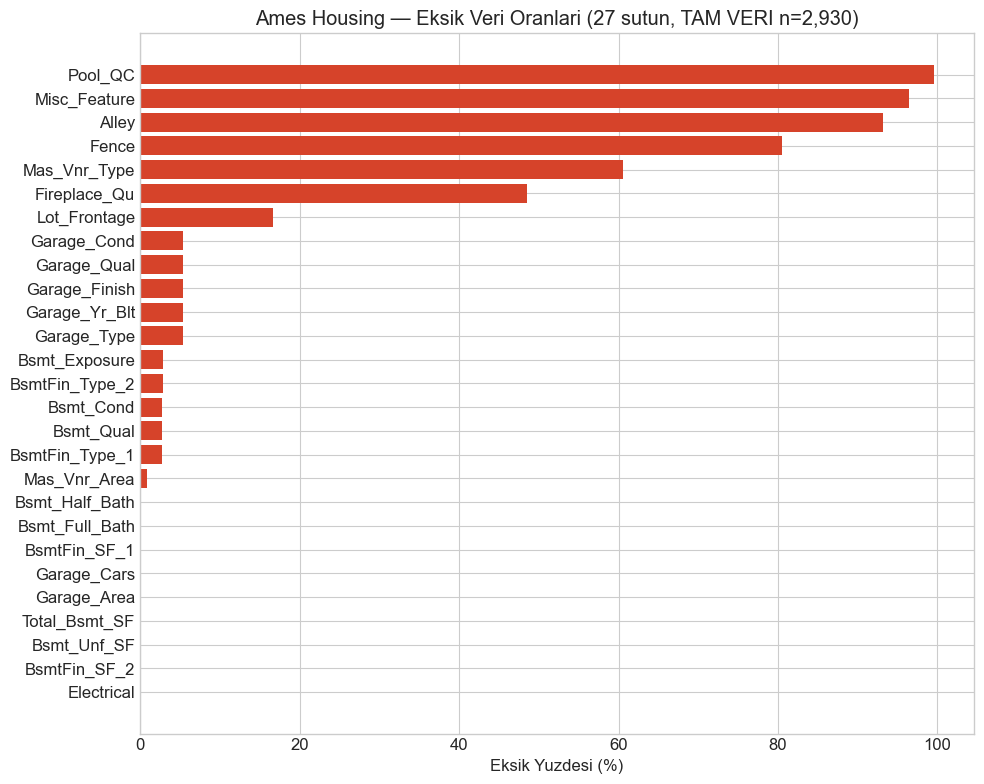

In [45]:
missing_ames = ames.isna().sum()
missing_ames = missing_ames[missing_ames > 0].sort_values(ascending=False)
missing_pct = (missing_ames / len(ames) * 100).round(1)

print(f"Ames'te eksik degeri olan sutun sayisi: {len(missing_ames)} / {ames.shape[1]}")
print(f"Diabetes'te NaN sayisi: {diabetes.isna().sum().sum()}  (ama dikkat, Python 6'ya bak!)")
print(f"Wine'da NaN sayisi: {wine.isna().sum().sum()}")

plt.figure(figsize=(10, 8))
plt.barh(missing_ames.index[::-1], missing_pct.values[::-1], color='#d6432a')
plt.xlabel('Eksik Yuzdesi (%)')
plt.title(f'Ames Housing — Eksik Veri Oranlari ({len(missing_ames)} sutun, TAM VERI n={len(ames):,})')
plt.tight_layout()
plt.show()

### 🧮 Python 3 — Mean / Median / Mode Imputation: `Lot_Frontage` ve `Electrical` (Ames)

**Ne yapıyoruz?**
`Lot_Frontage` (sokak cephesi genişliği, %16.7 eksik, çarpıklık $\approx 1.5$ olduğu için **median** tercih ediyoruz) ve `Electrical` (elektrik sistemi, sadece 1 eksik, kategorik olduğu için **mode**) sütunlarını dolduruyoruz. Bölüm 3.3'teki iddiayı sayısal olarak doğruluyoruz: imputation sonrası **varyansın küçüldüğünü** gösteriyoruz.

Lot_Frontage medyani: 68.0
Std (oncesi, eksikler haric)     : 23.37
Std (sonrasi, median ile dolu)   : 21.33  <- kuculdu (varyans daralmasi)

Electrical modu: 'SBrkr' -> 1 eksik satir bu degerle dolduruldu


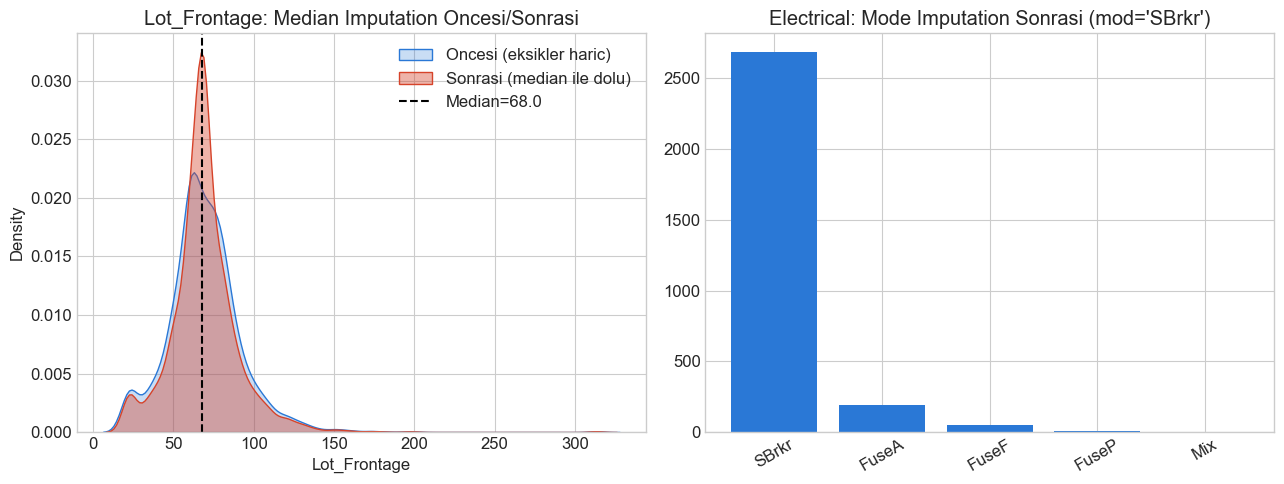

In [46]:
lot_frontage_before = ames['Lot_Frontage'].copy()
median_val = ames['Lot_Frontage'].median()
lot_frontage_median_imputed = ames['Lot_Frontage'].fillna(median_val)

mode_val = ames['Electrical'].mode()[0]
electrical_imputed = ames['Electrical'].fillna(mode_val)

print(f"Lot_Frontage medyani: {median_val}")
print(f"Std (oncesi, eksikler haric)     : {lot_frontage_before.std():.2f}")
print(f"Std (sonrasi, median ile dolu)   : {lot_frontage_median_imputed.std():.2f}  <- kuculdu (varyans daralmasi)")
print(f"\nElectrical modu: '{mode_val}' -> 1 eksik satir bu degerle dolduruldu")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.kdeplot(lot_frontage_before.dropna(), ax=axes[0], fill=True, color='#2a78d6', label='Oncesi (eksikler haric)')
sns.kdeplot(lot_frontage_median_imputed, ax=axes[0], fill=True, color='#d6432a', alpha=0.4, label='Sonrasi (median ile dolu)')
axes[0].axvline(median_val, color='black', linestyle='--', label=f'Median={median_val}')
axes[0].set_title('Lot_Frontage: Median Imputation Oncesi/Sonrasi')
axes[0].legend()

axes[1].bar(electrical_imputed.value_counts().index, electrical_imputed.value_counts().values, color='#2a78d6')
axes[1].set_title(f"Electrical: Mode Imputation Sonrasi (mod='{mode_val}')")
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### 🏊 Python 4 — Yapısal Eksiklik (MNAR) ve Eksiklik Göstergesi: Ames'in "Havuzsuz Ev" Problemi

**Ne yapıyoruz?**
`Pool_QC`, `Fireplace_Qu`, `Fence`, `Alley`, `Misc_Feature` gibi sütunlardaki `NaN`'lar rastgele değil — **o özelliğin evde bulunmadığı** anlamına gelir (Bölüm 3.6). Bunları istatistiksel bir yöntemle "tahmin etmek" yerine açıkça `"None"` ile dolduruyoruz, ayrıca ikili bir `Has_Pool` / `Has_Fireplace` göstergesi ekliyoruz — bu, "yapısal eksiklik = bilgi" fikrinin doğrudan uygulaması.

In [47]:
structural_na_cols = {
    'Pool_QC': 'Havuz kalitesi -> havuz yok',
    'Fireplace_Qu': 'Somine kalitesi -> somine yok',
    'Fence': 'Cit tipi -> cit yok',
    'Alley': 'Sokak erisimi -> sokak yok',
    'Misc_Feature': 'Ek ozellik -> ek ozellik yok',
    'Garage_Type': 'Garaj tipi -> garaj yok',
    'Bsmt_Qual': 'Bodrum kalitesi -> bodrum yok',
}

for col, aciklama in structural_na_cols.items():
    n_na_before = ames[col].isna().sum()
    indicator_name = 'Has_' + col.split('_')[0]
    if indicator_name not in ames.columns:
        ames[indicator_name] = (~ames[col].isna()).astype(int)
    ames[col] = ames[col].fillna('None')
    print(f"{col:18s} ({aciklama:30s}): {n_na_before:4d} NaN -> 'None' dolduruldu, {indicator_name} eklendi")

print(f"\nOrnek: Has_Pool dagilimi -> {ames['Has_Pool'].value_counts().to_dict()}  (yani {ames['Has_Pool'].sum()} evde gercekten havuz var)")
ames[['Pool_QC', 'Has_Pool', 'Fireplace_Qu', 'Has_Fireplace']].sample(5, random_state=42)

Pool_QC            (Havuz kalitesi -> havuz yok   ): 2917 NaN -> 'None' dolduruldu, Has_Pool eklendi
Fireplace_Qu       (Somine kalitesi -> somine yok ): 1422 NaN -> 'None' dolduruldu, Has_Fireplace eklendi
Fence              (Cit tipi -> cit yok           ): 2358 NaN -> 'None' dolduruldu, Has_Fence eklendi
Alley              (Sokak erisimi -> sokak yok    ): 2732 NaN -> 'None' dolduruldu, Has_Alley eklendi
Misc_Feature       (Ek ozellik -> ek ozellik yok  ): 2824 NaN -> 'None' dolduruldu, Has_Misc eklendi
Garage_Type        (Garaj tipi -> garaj yok       ):  157 NaN -> 'None' dolduruldu, Has_Garage eklendi
Bsmt_Qual          (Bodrum kalitesi -> bodrum yok ):   80 NaN -> 'None' dolduruldu, Has_Bsmt eklendi

Ornek: Has_Pool dagilimi -> {0: 2917, 1: 13}  (yani 13 evde gercekten havuz var)


,Pool_QC,Has_Pool,Fireplace_Qu,Has_Fireplace
1357,None,0,Gd,1
2367,None,0,None,0
2822,None,0,Gd,1
2126,None,0,None,0
1544,None,0,None,0


### 🩺 Python 5 — Gizlenmiş Eksik Veri: Diabetes'teki "İmkansız Sıfırlar"

**Ne yapıyoruz?**
Pima Diabetes veri setinde hiç `NaN` yok — ama `Glucose=0`, `BloodPressure=0`, `SkinThickness=0`, `Insulin=0`, `BMI=0` fizyolojik olarak **imkansızdır** (yaşayan bir insanın kan şekeri veya tansiyonu asla tam sıfır olamaz). Bu, veri toplama sırasında eksik değerlerin `0` ile kodlandığı, gerçek dünyada çok sık karşılaşılan bir tuzaktır — sadece `isna()`'ya bakmak bunu **tamamen kaçırır**. Alan bilgisiyle bu sıfırları gerçek `NaN`'a çeviriyoruz.

Sifirdan NaN'a cevrilen sutunlar ve eksiklik oranlari:
  Glucose         :   5 / 768  (%0.7)
  BloodPressure   :  35 / 768  (%4.6)
  SkinThickness   : 227 / 768  (%29.6)
  Insulin         : 374 / 768  (%48.7)
  BMI             :  11 / 768  (%1.4)


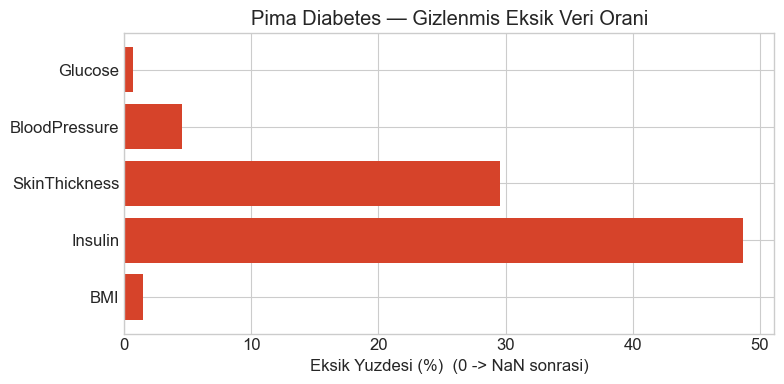

In [48]:
zero_as_missing_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
diabetes_clean = diabetes.copy()
diabetes_clean[zero_as_missing_cols] = diabetes_clean[zero_as_missing_cols].replace(0, np.nan)

print("Sifirdan NaN'a cevrilen sutunlar ve eksiklik oranlari:")
for col in zero_as_missing_cols:
    n_missing = diabetes_clean[col].isna().sum()
    print(f"  {col:16s}: {n_missing:3d} / {len(diabetes_clean)}  (%{100*n_missing/len(diabetes_clean):.1f})")

fig, ax = plt.subplots(figsize=(8, 4))
pct = diabetes_clean[zero_as_missing_cols].isna().mean() * 100
ax.barh(pct.index[::-1], pct.values[::-1], color='#d6432a')
ax.set_xlabel('Eksik Yuzdesi (%)  (0 -> NaN sonrasi)')
ax.set_title('Pima Diabetes — Gizlenmis Eksik Veri Orani')
plt.tight_layout()
plt.show()

### 🔗 Python 6 — KNN Imputation: Diabetes'te İlişkili Değişkenlerle Doldurma

**Ne yapıyoruz?**
`KNNImputer`, mesafe hesabı kullandığı için (Bölüm 3.4) önce **ölçekliyoruz** (`StandardScaler`), sonra dolduruyoruz, sonra orijinal ölçeğe geri döndürüyoruz (`inverse_transform`). $k=5$ komşu kullanıyoruz — Insulin gibi Glucose ile ilişkili bir değişken için bu, tek başına mean imputation'dan çok daha "veriye duyarlı" bir tahmin üretir.

In [49]:
num_cols = diabetes_clean.columns.drop('Outcome')

scaler_knn = StandardScaler()
diabetes_scaled = scaler_knn.fit_transform(diabetes_clean[num_cols])

knn_imputer = KNNImputer(n_neighbors=5)
diabetes_knn_scaled = knn_imputer.fit_transform(diabetes_scaled)

diabetes_knn = diabetes_clean.copy()
diabetes_knn[num_cols] = scaler_knn.inverse_transform(diabetes_knn_scaled)

print("KNN Imputation sonrasi kalan NaN sayisi:", diabetes_knn[num_cols].isna().sum().sum())
print(f"\nInsulin (n_neighbors=5 ile dolduruldu) - once/sonra ozet:")
print(f"  Gozlenen (NaN haric) ortalama : {diabetes_clean['Insulin'].mean():.1f}")
print(f"  KNN sonrasi tam veri ortalama : {diabetes_knn['Insulin'].mean():.1f}")
diabetes_knn[['Glucose', 'Insulin', 'BMI']].head(3)

KNN Imputation sonrasi kalan NaN sayisi: 0

Insulin (n_neighbors=5 ile dolduruldu) - once/sonra ozet:
  Gozlenen (NaN haric) ortalama : 155.5
  KNN sonrasi tam veri ortalama : 153.7


,Glucose,Insulin,BMI
0,148.0,264.8,33.6
1,85.0,65.2,26.6
2,183.0,198.2,23.3


### 🔁 Python 7 — Iterative Imputer (MICE): Çok Değişkenli Doldurma ve Yöntem Karşılaştırması

**Ne yapıyoruz?**
`IterativeImputer` (scikit-learn'ün MICE uygulaması) her eksik sütunu diğer tüm sütunları kullanan bir regresyonla, birkaç tur tekrarlayarak dolduruyor (Bölüm 3.5). En çok eksik değeri olan `Insulin` (%48.7) üzerinde **dört yöntemi aynı grafikte** karşılaştırıyoruz: gözlenen (eksikler hariç) dağılım, mean imputation, KNN imputation, MICE — hangi yöntemin orijinal dağılımın **şeklini** en iyi koruduğunu görsel olarak değerlendiriyoruz.

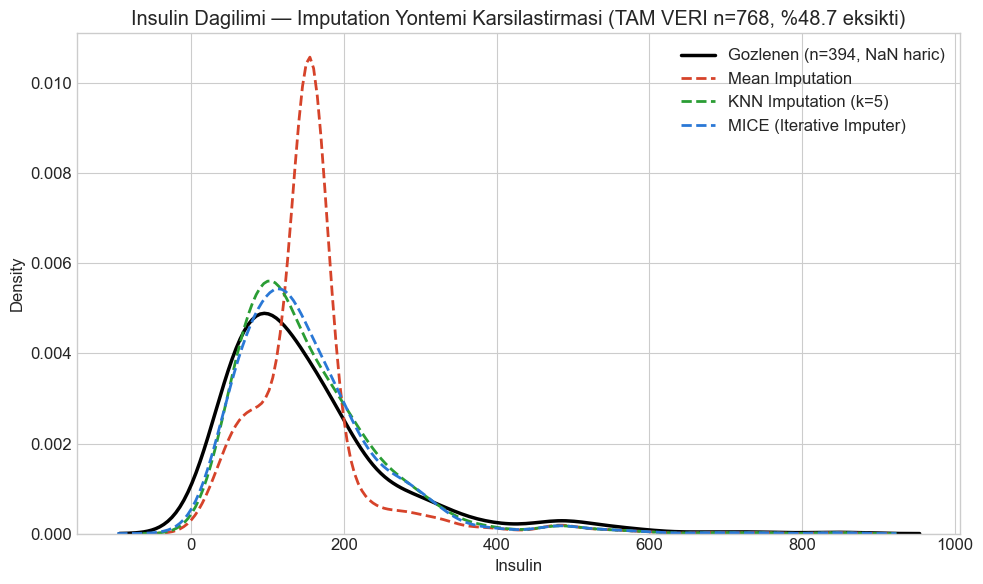

Std karsilastirmasi (varyans daralmasi en cok mean'de, en az MICE/KNN'de gorulur):
  Gozlenen (NaN haric) : 118.8
  Mean Imputation      : 85.0
  KNN Imputation       : 97.8
  MICE                 : 97.3


In [50]:
mice_imputer = IterativeImputer(random_state=42, max_iter=15)
diabetes_mice_arr = mice_imputer.fit_transform(diabetes_clean[num_cols])
diabetes_mice = diabetes_clean.copy()
diabetes_mice[num_cols] = diabetes_mice_arr

mean_imputer = SimpleImputer(strategy='mean')
diabetes_mean = diabetes_clean.copy()
diabetes_mean[num_cols] = mean_imputer.fit_transform(diabetes_clean[num_cols])

plt.figure(figsize=(10, 6))
sns.kdeplot(diabetes_clean['Insulin'].dropna(), label=f"Gozlenen (n={diabetes_clean['Insulin'].notna().sum()}, NaN haric)", linewidth=2.5, color='black')
sns.kdeplot(diabetes_mean['Insulin'], label='Mean Imputation', linewidth=2, linestyle='--', color='#d6432a')
sns.kdeplot(diabetes_knn['Insulin'], label='KNN Imputation (k=5)', linewidth=2, linestyle='--', color='#2a9d34')
sns.kdeplot(diabetes_mice['Insulin'], label='MICE (Iterative Imputer)', linewidth=2, linestyle='--', color='#2a78d6')
plt.title(f"Insulin Dagilimi — Imputation Yontemi Karsilastirmasi (TAM VERI n={len(diabetes_clean)}, %48.7 eksikti)")
plt.xlabel('Insulin')
plt.legend()
plt.tight_layout()
plt.show()

print("Std karsilastirmasi (varyans daralmasi en cok mean'de, en az MICE/KNN'de gorulur):")
print(f"  Gozlenen (NaN haric) : {diabetes_clean['Insulin'].std():.1f}")
print(f"  Mean Imputation      : {diabetes_mean['Insulin'].std():.1f}")
print(f"  KNN Imputation       : {diabetes_knn['Insulin'].std():.1f}")
print(f"  MICE                 : {diabetes_mice['Insulin'].std():.1f}")

### 📏 Python 8 — IQR Kuralı ile Aykırı Değer Tespiti: `Wine`'da `total_sulfur_dioxide` (TAM VERİ, n=1.599)

**Ne yapıyoruz?**
Tukey'in $1.5\times IQR$ kuralını (Bölüm 4.1) `total_sulfur_dioxide` ve `residual_sugar` sütunlarına uyguluyoruz — hiç örneklem almadan, verinin tamamıyla. Kaç gözlemin aykırı sayıldığını ve boxplot üzerinde nerede olduklarını gösteriyoruz.

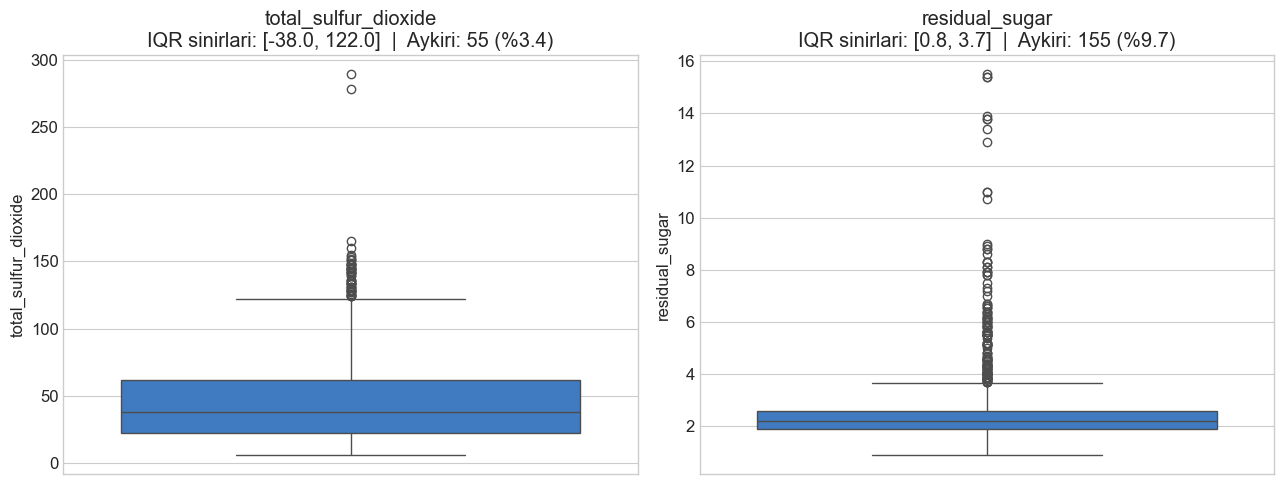

total_sulfur_dioxide: 55 aykiri deger (tam veri n=1599 uzerinden, hicbir sey silinmedi)


In [51]:
def iqr_outliers(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col in zip(axes, ['total_sulfur_dioxide', 'residual_sugar']):
    mask, lower, upper = iqr_outliers(wine[col])
    sns.boxplot(y=wine[col], ax=ax, color='#2a78d6')
    ax.set_title(f"{col}\nIQR sinirlari: [{lower:.1f}, {upper:.1f}]  |  Aykiri: {mask.sum()} (%{100*mask.mean():.1f})")
plt.tight_layout()
plt.show()

mask_sulfur, lower_s, upper_s = iqr_outliers(wine['total_sulfur_dioxide'])
print(f"total_sulfur_dioxide: {mask_sulfur.sum()} aykiri deger (tam veri n={len(wine)} uzerinden, hicbir sey silinmedi)")

### 📐 Python 9 — Z-Score vs Modified Z-Score: Hangisi Kaç Aykırı Değer Buluyor?

**Ne yapıyoruz?**
Aynı sütun (`total_sulfur_dioxide`) üzerinde klasik Z-Score (`|z|>3`) ile sağlam Modified Z-Score'u (`|M|>3.5`, Bölüm 4.2) karşılaştırıyoruz. Klasik z-score'un ortalama/std'sinin aykırı değerlerden etkilendiğini, bu yüzden IQR ve Modified Z-Score ile biraz farklı sonuç verdiğini gösteriyoruz.

IQR (1.5x)         : 55 aykiri deger
Z-Score (|z|>3)     : 15 aykiri deger
Modified Z (|M|>3.5): 38 aykiri deger

Uc yontemin de aykiri saydigi ortak gozlem sayisi: 15


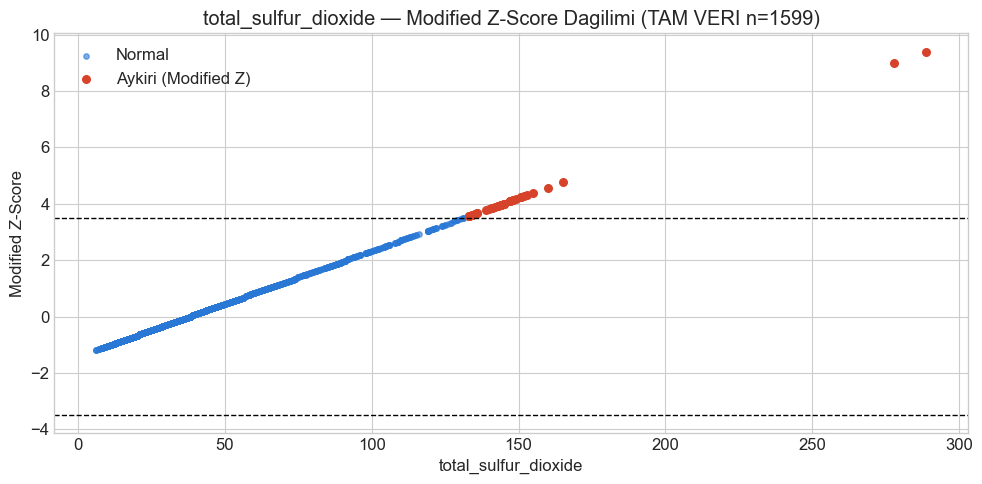

In [52]:
col = 'total_sulfur_dioxide'
x = wine[col]

z_scores = (x - x.mean()) / x.std()
mask_z = z_scores.abs() > 3

median_x = x.median()
mad = (x - median_x).abs().median()
modified_z = 0.6745 * (x - median_x) / mad
mask_mz = modified_z.abs() > 3.5

print(f"IQR (1.5x)         : {mask_sulfur.sum()} aykiri deger")
print(f"Z-Score (|z|>3)     : {mask_z.sum()} aykiri deger")
print(f"Modified Z (|M|>3.5): {mask_mz.sum()} aykiri deger")
print(f"\nUc yontemin de aykiri saydigi ortak gozlem sayisi: {(mask_sulfur & mask_z & mask_mz).sum()}")

plt.figure(figsize=(10, 5))
plt.scatter(x[~mask_mz], modified_z[~mask_mz], color='#2a78d6', s=15, label='Normal', alpha=0.6)
plt.scatter(x[mask_mz], modified_z[mask_mz], color='#d6432a', s=30, label='Aykiri (Modified Z)')
plt.axhline(3.5, color='black', linestyle='--', linewidth=1)
plt.axhline(-3.5, color='black', linestyle='--', linewidth=1)
plt.xlabel(col)
plt.ylabel('Modified Z-Score')
plt.title(f'{col} — Modified Z-Score Dagilimi (TAM VERI n={len(wine)})')
plt.legend()
plt.tight_layout()
plt.show()

### ✂️ Python 10 — Winsorizing / Capping: Aykırı Değeri Silmeden Etkisini Sınırlama

**Ne yapıyoruz?**
Bölüm 4.3'teki dört seçenekten "capping"i uyguluyoruz: IQR sınırlarının dışındaki değerleri **silmek yerine sınıra sıkıştırıyoruz** (`clip`). Öncesi/sonrası boxplot ve özet istatistiklerle veri kaybı olmadan aykırılığın etkisinin nasıl sınırlandığını gösteriyoruz.

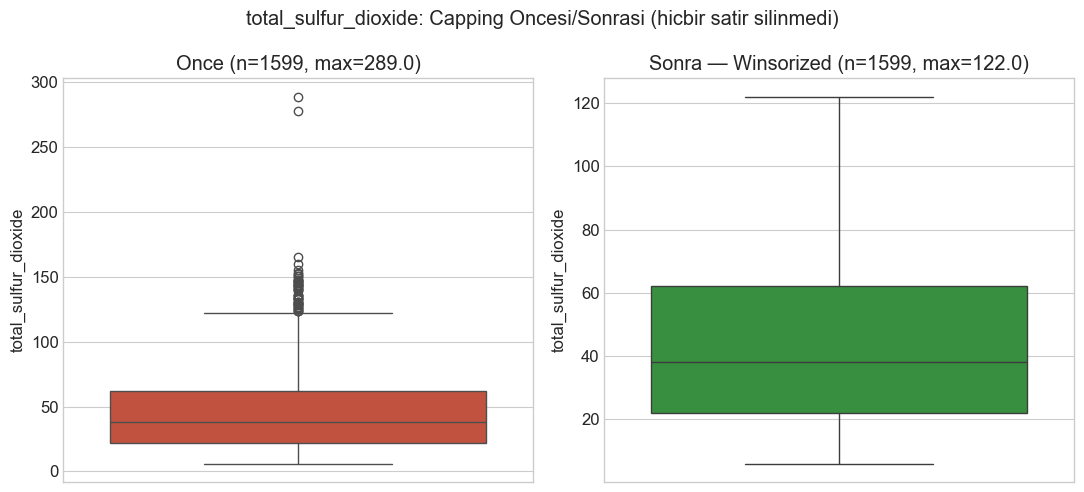

Std once: 32.90  |  Std sonra (capped): 30.37


In [53]:
wine_capped = wine.copy()
wine_capped[col] = wine[col].clip(lower=lower_s, upper=upper_s)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sns.boxplot(y=wine[col], ax=axes[0], color='#d6432a')
axes[0].set_title(f'Once (n={len(wine)}, max={wine[col].max()})')
sns.boxplot(y=wine_capped[col], ax=axes[1], color='#2a9d34')
axes[1].set_title(f'Sonra — Winsorized (n={len(wine_capped)}, max={wine_capped[col].max():.1f})')
plt.suptitle(f'{col}: Capping Oncesi/Sonrasi (hicbir satir silinmedi)')
plt.tight_layout()
plt.show()

print(f"Std once: {wine[col].std():.2f}  |  Std sonra (capped): {wine_capped[col].std():.2f}")

### 🏷️ Python 11 — One-Hot Encoding: `MS_Zoning` (Ames)

**Ne yapıyoruz?**
Düşük kardinaliteli, sırasız (nominal) bir sütun olan `MS_Zoning`'i (imar bölgesi tipi) One-Hot encode ediyoruz. Hem `pd.get_dummies` (hızlı, keşifsel analiz için) hem de `OneHotEncoder` (train/test tutarlılığı ve `Pipeline` uyumu için üretim kodunda tercih edilir, Bölüm 5.1) ile gösteriyoruz — dummy variable trap'ten kaçınmak için `drop_first=True` / `drop='first'` kullanıyoruz.

In [54]:
print("MS_Zoning kategorileri:", ames['MS_Zoning'].unique())

ames_ohe_pandas = pd.get_dummies(ames[['MS_Zoning']], columns=['MS_Zoning'], drop_first=True)
print(f"\npd.get_dummies (drop_first=True) -> {ames_ohe_pandas.shape[1]} sutun:")
print(ames_ohe_pandas.columns.tolist())

ohe = OneHotEncoder(drop='first', sparse_output=False)
ohe_array = ohe.fit_transform(ames[['MS_Zoning']])
print(f"\nsklearn OneHotEncoder(drop='first') -> {ohe_array.shape[1]} sutun (ayni sonuc, Pipeline'a uyumlu):")
print(ohe.get_feature_names_out())
ames_ohe_pandas.head(3)

MS_Zoning kategorileri: ['RL' 'RH' 'FV' 'RM' 'C (all)' 'I (all)' 'A (agr)']

pd.get_dummies (drop_first=True) -> 6 sutun:
['MS_Zoning_C (all)', 'MS_Zoning_FV', 'MS_Zoning_I (all)', 'MS_Zoning_RH', 'MS_Zoning_RL', 'MS_Zoning_RM']

sklearn OneHotEncoder(drop='first') -> 6 sutun (ayni sonuc, Pipeline'a uyumlu):
['MS_Zoning_C (all)' 'MS_Zoning_FV' 'MS_Zoning_I (all)' 'MS_Zoning_RH'
 'MS_Zoning_RL' 'MS_Zoning_RM']


,MS_Zoning_C (all),MS_Zoning_FV,MS_Zoning_I (all),MS_Zoning_RH,MS_Zoning_RL,MS_Zoning_RM
0,False,False,False,False,True,False
1,False,False,False,True,False,False
2,False,False,False,False,True,False


### ⚠️ Python 12 — Label Encoding ve Tuzağı: `Neighborhood`'da Sahte Sıra

**Ne yapıyoruz?**
28 kategorili, **sırasız** `Neighborhood` sütununu `LabelEncoder` ile sayısallaştırıyoruz — sonra bu sayıların aslında **hiçbir gerçek sıra taşımadığını** ama bir KNN/lineer modelin bunları sanki sıralıymış gibi yorumlayacağını sayısal olarak gösteriyoruz (Bölüm 5.2): iki komşu kod (örn. 3 ve 4) alfabetik olarak yan yana gelen mahallelerdir, ev fiyatı açısından yakınlıkla hiçbir ilgisi yoktur.

In [55]:
le = LabelEncoder()
ames['Neighborhood_label'] = le.fit_transform(ames['Neighborhood'])

label_check = ames.groupby('Neighborhood_label').agg(
    Neighborhood=('Neighborhood', 'first'),
    Ortalama_SalePrice=('SalePrice', 'mean')
).sort_index()

print("Label Encoding sonucu (ilk 6 satir) - Label sirasi ile fiyat siralamasi ARASINDA hicbir iliski YOK:")
print(label_check.head(6).round(0))

corr_label_price = ames[['Neighborhood_label', 'SalePrice']].corr().iloc[0, 1]
print(f"\nNeighborhood_label ile SalePrice arasindaki (anlamsiz) korelasyon: {corr_label_price:.3f}")
print("-> Bu sayi neredeyse sifira yakin/rastgele cikar, cunku alfabetik siranin fiyatla hicbir mantiksal baglantisi yok.")
print("   Bir sonraki adimda (Target Encoding) ayni mahalle bilgisini ANLAMLI bir sirayla kodlayacagiz.")

Label Encoding sonucu (ilk 6 satir) - Label sirasi ile fiyat siralamasi ARASINDA hicbir iliski YOK:
                   Neighborhood  Ortalama_SalePrice
Neighborhood_label                                 
0                       Blmngtn            196662.0
1                       Blueste            143590.0
2                        BrDale            105608.0
3                       BrkSide            124756.0
4                       ClearCr            208662.0
5                       CollgCr            201803.0

Neighborhood_label ile SalePrice arasindaki (anlamsiz) korelasyon: 0.200
-> Bu sayi neredeyse sifira yakin/rastgele cikar, cunku alfabetik siranin fiyatla hicbir mantiksal baglantisi yok.
   Bir sonraki adimda (Target Encoding) ayni mahalle bilgisini ANLAMLI bir sirayla kodlayacagiz.


### 📊 Python 13 — Ordinal Encoding: Kalite Skalaları (`Exter_Qual`, `Kitchen_Qual`)

**Ne yapıyoruz?**
Ames'te `Po < Fa < TA < Gd < Ex` (Poor → Excellent) gibi **gerçek bir sırası olan** kategorik sütunlar var. Bu sırayı elle tanımlayıp `OrdinalEncoder` ile kodluyoruz — Label Encoding'in aksine, bu sefer sayısal sıra **gerçekten anlamlı**: `Ex (5) - TA (3) = 2` birimlik bir kalite farkını temsil ediyor.

Exter_Qual: ordinal kod arttikca ortalama fiyat da DUZENLI arttigini goruyoruz (Label Encoding'in aksine):
            Ordinal_Kod  Ortalama_SalePrice    Adet
Exter_Qual                                         
Po                  NaN                 NaN     NaN
Fa                  1.0             89924.0    35.0
TA                  2.0            143374.0  1799.0
Gd                  3.0            230756.0   989.0
Ex                  4.0            377919.0   107.0


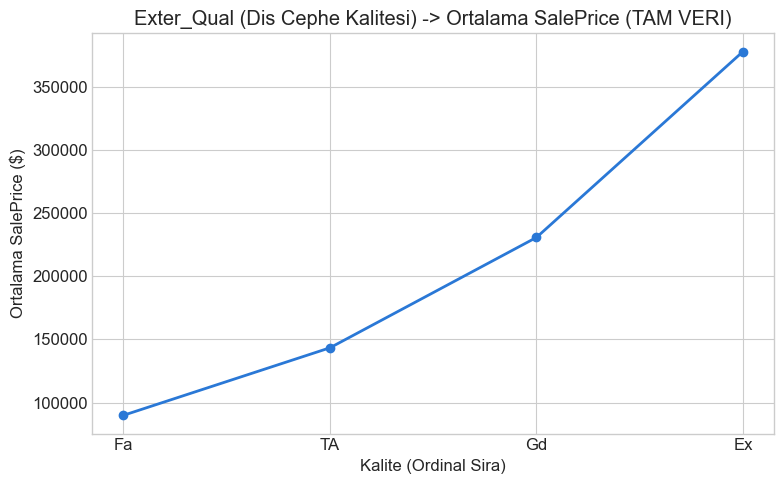

In [56]:
quality_order = ['Po', 'Fa', 'TA', 'Gd', 'Ex']

ordinal_encoder = OrdinalEncoder(categories=[quality_order, quality_order])
ames[['Exter_Qual_ord', 'Kitchen_Qual_ord']] = ordinal_encoder.fit_transform(ames[['Exter_Qual', 'Kitchen_Qual']])

check = ames[['Exter_Qual', 'Exter_Qual_ord', 'SalePrice']].groupby('Exter_Qual').agg(
    Ordinal_Kod=('Exter_Qual_ord', 'first'),
    Ortalama_SalePrice=('SalePrice', 'mean'),
    Adet=('SalePrice', 'size')
).reindex(quality_order)

print("Exter_Qual: ordinal kod arttikca ortalama fiyat da DUZENLI arttigini goruyoruz (Label Encoding'in aksine):")
print(check.round(0))

plt.figure(figsize=(8, 5))
plt.plot(check.index, check['Ortalama_SalePrice'], marker='o', linewidth=2, color='#2a78d6')
plt.title('Exter_Qual (Dis Cephe Kalitesi) -> Ortalama SalePrice (TAM VERI)')
plt.xlabel('Kalite (Ordinal Sira)')
plt.ylabel('Ortalama SalePrice ($)')
plt.tight_layout()
plt.show()

### 🎯 Python 14 — Target (Mean) Encoding + Smoothing: `Neighborhood` → `SalePrice`

**Ne yapıyoruz?**
28 kategorili `Neighborhood`'u, Label Encoding'in aksine **gerçekten anlamlı** bir sırayla kodluyoruz: her mahallenin ortalama `SalePrice`'ı (Bölüm 5.4). Az gözlemli mahallelerde (örn. 5-10 ev) ham ortalamanın gürültülü olduğunu gösterip **smoothing** formülünü uyguluyoruz — küçük mahalleler global ortalamaya doğru çekiliyor. **Leakage uyarısını** açıkça not ediyoruz: gerçek bir projede bu, sadece train fold'unda hesaplanmalı.

In [57]:
global_mean = ames['SalePrice'].mean()
stats_by_neighborhood = ames.groupby('Neighborhood')['SalePrice'].agg(['mean', 'count'])

m = 10  # smoothing parametresi: kac 'sahte' gozlem kadar global ortalamaya guvenelim
stats_by_neighborhood['smoothed_mean'] = (
    stats_by_neighborhood['count'] * stats_by_neighborhood['mean'] + m * global_mean
) / (stats_by_neighborhood['count'] + m)

ames['Neighborhood_target_enc'] = ames['Neighborhood'].map(stats_by_neighborhood['smoothed_mean'])

smallest = stats_by_neighborhood.sort_values('count').head(5)
print(f"Global ortalama SalePrice: {global_mean:,.0f}\n")
print("En az gozlemli 5 mahallede ham ortalama vs smoothed (m=10) karsilastirmasi:")
print(f"{'Mahalle':12s} {'n':>4s} {'Ham Ortalama':>14s} {'Smoothed':>12s}")
for name, row in smallest.iterrows():
    print(f"{name:12s} {int(row['count']):4d} {row['mean']:14,.0f} {row['smoothed_mean']:12,.0f}")
print("\n-> Kucuk n'li mahalleler global ortalamaya dogru cekildi (asiri guven/overfitting azaldi).")
print("UYARI: Bu ortalama TUM veri uzerinden hesaplandi (gosterim amacli); gercek bir modelde")
print("       sadece egitim (train) foldunda hesaplanip test'e uygulanmalidir (leakage onlemi).")

Global ortalama SalePrice: 180,796

En az gozlemli 5 mahallede ham ortalama vs smoothed (m=10) karsilastirmasi:
Mahalle         n   Ham Ortalama     Smoothed
Landmrk         1        137,000      176,815
GrnHill         2        280,000      197,330
Greens          8        193,531      186,456
Blueste        10        143,590      162,193
NPkVill        23        140,711      152,858

-> Kucuk n'li mahalleler global ortalamaya dogru cekildi (asiri guven/overfitting azaldi).
UYARI: Bu ortalama TUM veri uzerinden hesaplandi (gosterim amacli); gercek bir modelde
       sadece egitim (train) foldunda hesaplanip test'e uygulanmalidir (leakage onlemi).


### 🔢 Python 15 — Frequency (Count) Encoding: Leakage'sız Alternatif

**Ne yapıyoruz?**
Aynı `Neighborhood` sütununu, hedef değişkeni (`SalePrice`) hiç kullanmadan, sadece **görülme sıklığıyla** kodluyoruz (Bölüm 5.5) — leakage riski taşımayan, hızlı bir alternatif. Target Encoding'den farkını (bilgi zenginliği vs güvenlik) karşılaştırıyoruz.

In [58]:
freq_map = ames['Neighborhood'].value_counts(normalize=True)
ames['Neighborhood_freq_enc'] = ames['Neighborhood'].map(freq_map)

comparison = ames[['Neighborhood', 'Neighborhood_label', 'Neighborhood_target_enc', 'Neighborhood_freq_enc']].drop_duplicates('Neighborhood').sort_values('Neighborhood_target_enc', ascending=False)
print("Ayni sutunun 3 farkli kodlamasi (ilk 6 mahalle, fiyata gore siralanmis):")
comparison.head(6).round(3)

Ayni sutunun 3 farkli kodlamasi (ilk 6 mahalle, fiyata gore siralanmis):


,Neighborhood,Neighborhood_label,Neighborhood_target_enc,Neighborhood_freq_enc
36,NridgHt,19,313994.276,0.057
59,NoRidge,18,311859.489,0.024
6,StoneBr,25,300715.567,0.017
314,Timber,26,238574.727,0.025
563,Veenker,27,228456.194,0.008
22,Somerst,24,227159.863,0.062


### ⚖️ Python 16 — Standardization vs Min-Max vs Robust Scaling: Aykırı Değer Varken Kim Kazanıyor?

**Ne yapıyoruz?**
`total_sulfur_dioxide` (aykırı değer içeren, Python 8-10'da inceledik) üzerinde üç ölçekleyiciyi de uyguluyoruz ve sonuçları yan yana çiziyoruz (Bölüm 6.1-6.3). Beklenti: `MinMaxScaler`'ın aykırı değerlerden en çok etkilenen (aralığın çoğunu birkaç uç noktaya "kaptıran"), `RobustScaler`'ın en dayanıklı olması.

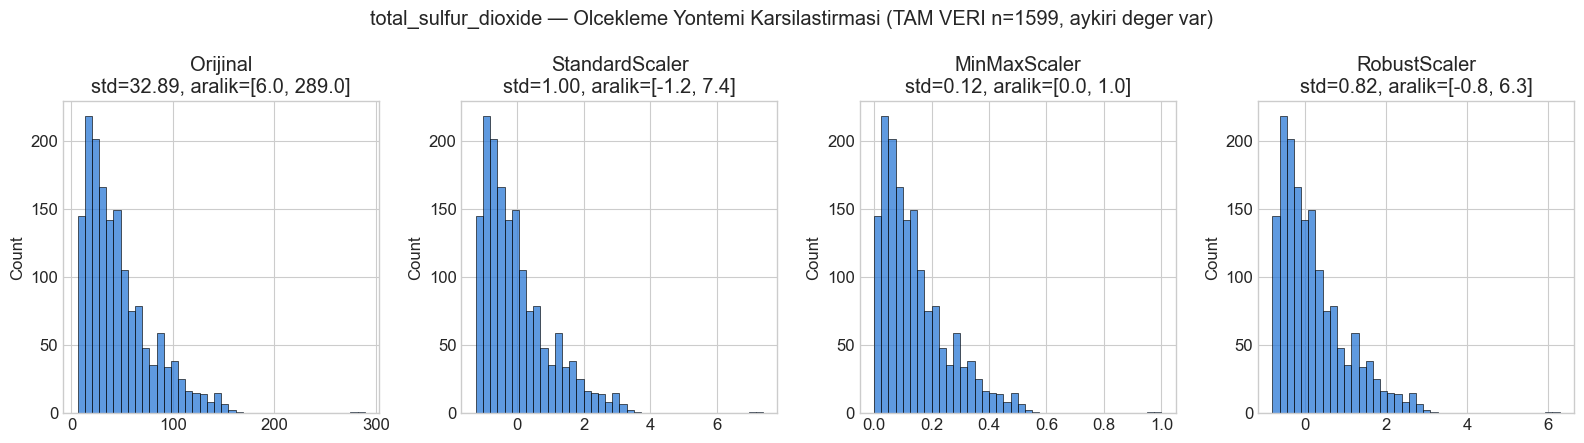

Not: MinMaxScaler'da 'normal' gozlemlerin cogu, birkac aykiri deger yuzunden 0'a yakin dar bir
     araliga sikisti -- RobustScaler'da ise merkez (medyan/IQR bazli) daha dengeli dagildi.


In [59]:
col = 'total_sulfur_dioxide'
x = wine[[col]].values

scalers = {
    'Orijinal': x.flatten(),
    'StandardScaler': StandardScaler().fit_transform(x).flatten(),
    'MinMaxScaler': MinMaxScaler().fit_transform(x).flatten(),
    'RobustScaler': RobustScaler().fit_transform(x).flatten(),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, (name, values) in zip(axes, scalers.items()):
    sns.histplot(values, ax=ax, bins=40, color='#2a78d6')
    ax.set_title(f"{name}\nstd={values.std():.2f}, aralik=[{values.min():.1f}, {values.max():.1f}]")
plt.suptitle(f'{col} — Olcekleme Yontemi Karsilastirmasi (TAM VERI n={len(wine)}, aykiri deger var)')
plt.tight_layout()
plt.show()

print("Not: MinMaxScaler'da 'normal' gozlemlerin cogu, birkac aykiri deger yuzunden 0'a yakin dar bir")
print("     araliga sikisti -- RobustScaler'da ise merkez (medyan/IQR bazli) daha dengeli dagildi.")

### 📉 Python 17 — Log Transform: `SalePrice` (Ames) ve `residual_sugar` (Wine)

**Ne yapıyoruz?**
İki sağa çarpık değişkeni `log1p` ile dönüştürüp çarpıklık (skewness) katsayısının nasıl düştüğünü sayısal ve görsel olarak gösteriyoruz (Bölüm 6.4). `PowerTransformer(method='yeo-johnson')` ile otomatik/optimal bir dönüşümü de karşılaştırma amaçlı ekliyoruz.

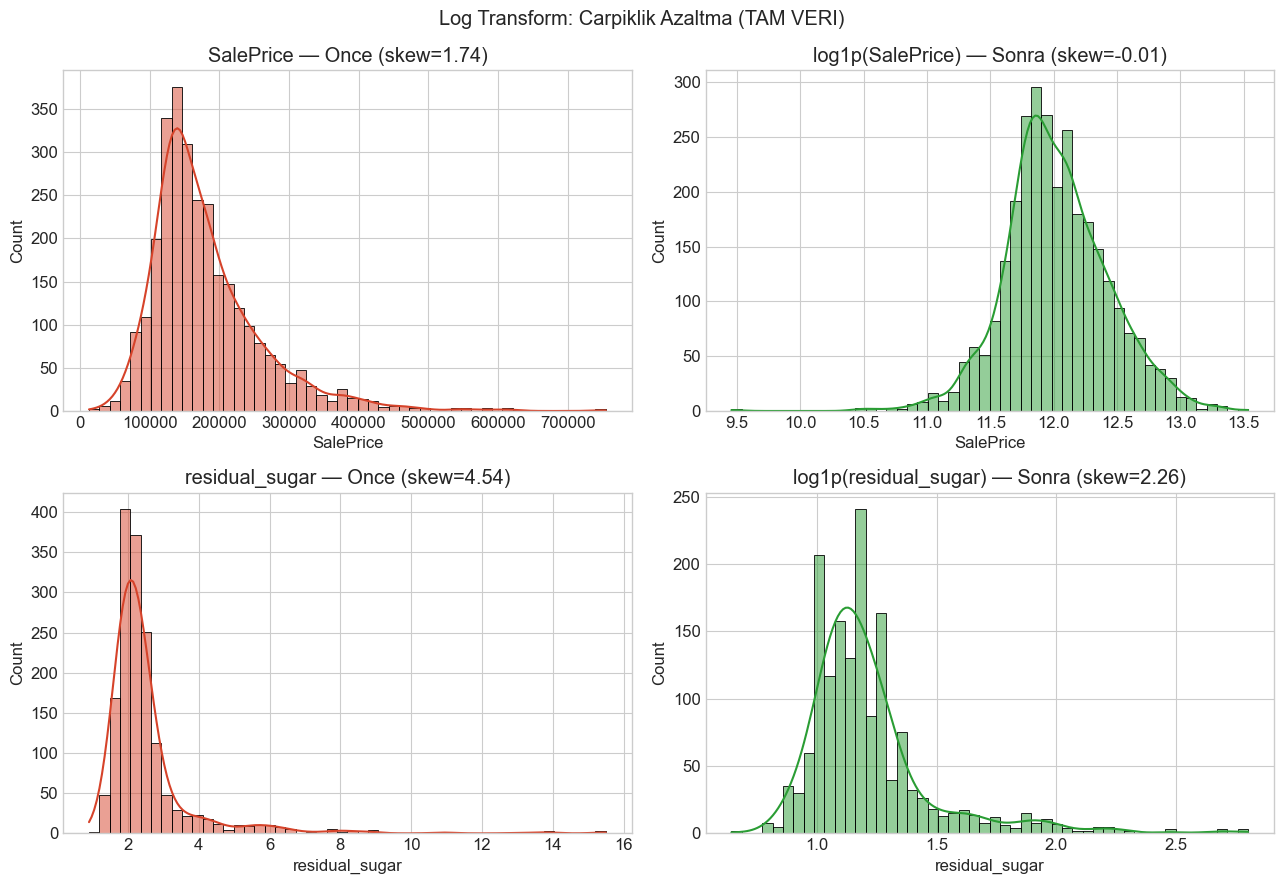

SalePrice skew  -> once: 1.74 | log1p sonrasi: -0.01 | Yeo-Johnson sonrasi: 0.00


In [60]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for row, (df_, col_) in enumerate([(ames, 'SalePrice'), (wine, 'residual_sugar')]):
    original = df_[col_]
    logged = np.log1p(original)
    sns.histplot(original, ax=axes[row, 0], bins=50, color='#d6432a', kde=True)
    axes[row, 0].set_title(f"{col_} — Once (skew={original.skew():.2f})")
    sns.histplot(logged, ax=axes[row, 1], bins=50, color='#2a9d34', kde=True)
    axes[row, 1].set_title(f"log1p({col_}) — Sonra (skew={logged.skew():.2f})")

plt.suptitle('Log Transform: Carpiklik Azaltma (TAM VERI)')
plt.tight_layout()
plt.show()

pt = PowerTransformer(method='yeo-johnson')
saleprice_yj = pt.fit_transform(ames[['SalePrice']]).flatten()
print(f"SalePrice skew  -> once: {ames['SalePrice'].skew():.2f} | log1p sonrasi: {np.log1p(ames['SalePrice']).skew():.2f} | Yeo-Johnson sonrasi: {pd.Series(saleprice_yj).skew():.2f}")

### 🛠️ Python 18 — Türetilmiş Özellikler: Ames'te "Toplam Alan" ve "Ev Yaşı"

**Ne yapıyoruz?**
Bölüm 7.1 ve 7.4'ü uyguluyoruz: `First_Flr_SF + Second_Flr_SF + Total_Bsmt_SF` toplamından `Total_SF` üretip bu tek özelliğin, üç ayrı bileşenin her birinden `SalePrice` ile **daha güçlü** korelasyonlu olduğunu gösteriyoruz; `Yr_Sold - Year_Built` ile `House_Age` (ev yaşı) ve `Yr_Sold - Year_Remod_Add` ile "son tadilattan bu yana geçen süre" hesaplıyoruz.

SalePrice ile korelasyon (turetilmis Total_SF, tek tek bilesenlerin hepsinden guclu):
Total_SF         0.793
Total_Bsmt_SF    0.632
First_Flr_SF     0.622
Second_Flr_SF    0.269
House_Age       -0.559
Name: SalePrice, dtype: float64


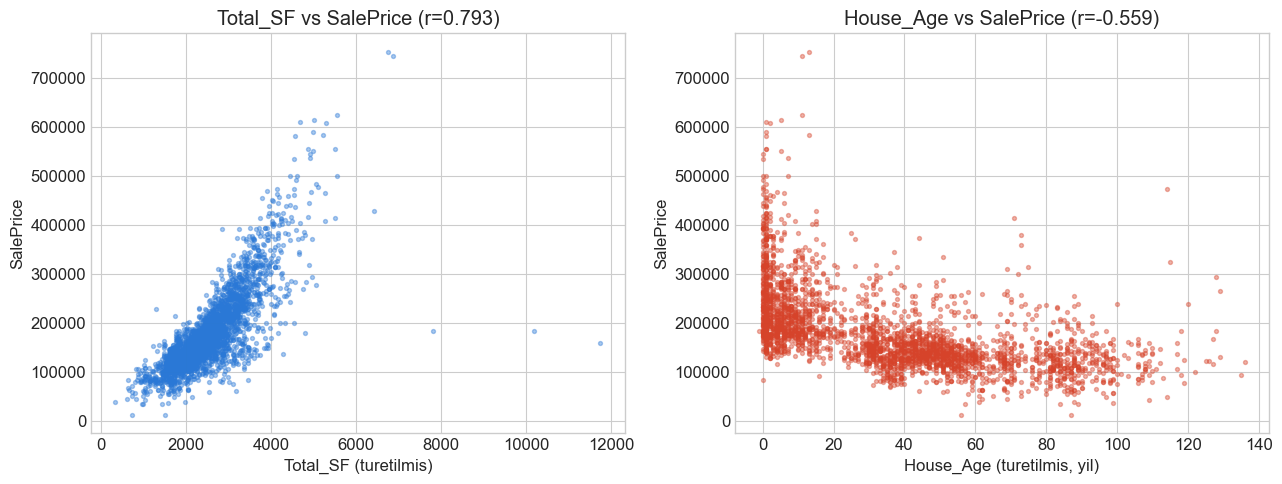

In [61]:
ames['Total_SF'] = ames['First_Flr_SF'] + ames['Second_Flr_SF'] + ames['Total_Bsmt_SF']
ames['House_Age'] = ames['Yr_Sold'] - ames['Year_Built']
ames['Years_Since_Remod'] = ames['Yr_Sold'] - ames['Year_Remod_Add']
ames['Is_Remodeled'] = (ames['Year_Built'] != ames['Year_Remod_Add']).astype(int)

corr_components = ames[['First_Flr_SF', 'Second_Flr_SF', 'Total_Bsmt_SF', 'Total_SF', 'House_Age', 'SalePrice']].corr()['SalePrice'].drop('SalePrice')
print("SalePrice ile korelasyon (turetilmis Total_SF, tek tek bilesenlerin hepsinden guclu):")
print(corr_components.sort_values(ascending=False).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(ames['Total_SF'], ames['SalePrice'], s=8, alpha=0.4, color='#2a78d6')
axes[0].set_xlabel('Total_SF (turetilmis)')
axes[0].set_ylabel('SalePrice')
axes[0].set_title(f"Total_SF vs SalePrice (r={corr_components['Total_SF']:.3f})")

axes[1].scatter(ames['House_Age'], ames['SalePrice'], s=8, alpha=0.4, color='#d6432a')
axes[1].set_xlabel('House_Age (turetilmis, yil)')
axes[1].set_ylabel('SalePrice')
axes[1].set_title(f"House_Age vs SalePrice (r={corr_components['House_Age']:.3f})")
plt.tight_layout()
plt.show()

### 🗂️ Python 19 — Binning / Diskretizasyon: `alcohol` (Wine) Eşit-Genişlik vs Eşit-Frekans

**Ne yapıyoruz?**
`alcohol` sütununu `pd.cut` (eşit genişlik) ve `pd.qcut` (eşit frekans, Bölüm 7.2) ile 4 kategoriye ayırıp iki yöntemin ürettiği aralıkları ve her aralıktaki gözlem sayısını karşılaştırıyoruz — eşit genişlikte gruplar arası gözlem sayısı dengesiz, eşit frekansta aralık genişlikleri dengesiz çıkar.

Esit GENISLIK (pd.cut) - her aralik ayni buyuklukte, gozlem sayilari dengesiz:
alcohol_bin_width
(8.394, 10.025]    747
(10.025, 11.65]    617
(11.65, 13.275]    215
(13.275, 14.9]      20
Name: count, dtype: int64

Esit FREKANS (pd.qcut) - her aralikta ~ayni sayida gozlem, genislikleri dengesiz:
alcohol_bin_freq
(8.399000000000001, 9.5]    436
(9.5, 10.2]                 406
(10.2, 11.1]                377
(11.1, 14.9]                380
Name: count, dtype: int64


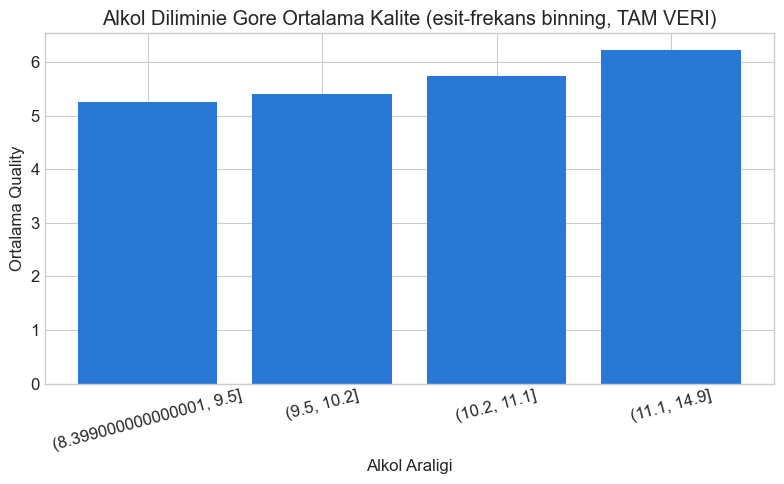

In [62]:
wine['alcohol_bin_width'] = pd.cut(wine['alcohol'], bins=4)
wine['alcohol_bin_freq'] = pd.qcut(wine['alcohol'], q=4)

print("Esit GENISLIK (pd.cut) - her aralik ayni buyuklukte, gozlem sayilari dengesiz:")
print(wine['alcohol_bin_width'].value_counts().sort_index())
print("\nEsit FREKANS (pd.qcut) - her aralikta ~ayni sayida gozlem, genislikleri dengesiz:")
print(wine['alcohol_bin_freq'].value_counts().sort_index())

quality_by_bin = wine.groupby('alcohol_bin_freq', observed=True)['quality'].mean()
plt.figure(figsize=(8, 5))
plt.bar(quality_by_bin.index.astype(str), quality_by_bin.values, color='#2a78d6')
plt.title('Alkol Diliminie Gore Ortalama Kalite (esit-frekans binning, TAM VERI)')
plt.xlabel('Alkol Araligi')
plt.ylabel('Ortalama Quality')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### ✖️ Python 20 — Etkileşim / Oran Özellikleri ve Polinom Terimler (Wine)

**Ne yapıyoruz?**
Bölüm 7.1 ve 7.3'ü birlikte uyguluyoruz: kimyasal olarak anlamlı bir **oran özelliği** (`free_sulfur_dioxide / total_sulfur_dioxide` = "serbest SO2 yüzdesi") üretiyoruz; ardından `PolynomialFeatures(degree=2)` ile 3 değişkenden otomatik üretilen etkileşim terimlerinin sayısının ne kadar hızlı büyüdüğünü gösteriyoruz.

In [63]:
wine['free_sulfur_ratio'] = wine['free_sulfur_dioxide'] / wine['total_sulfur_dioxide']

corr_ratio = wine[['free_sulfur_ratio', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'quality']].corr()['quality']
print("Oran ozelligi ile ham bilesenlerin 'quality' ile korelasyonu:")
print(corr_ratio.round(3))

base_cols = ['alcohol', 'volatile_acidity', 'sulphates']
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
poly_features = poly.fit_transform(wine[base_cols])
print(f"\n{len(base_cols)} degisken -> derece-2 PolynomialFeatures sonrasi {poly_features.shape[1]} sutun:")
print(poly.get_feature_names_out(base_cols))
print("-> Sadece 3 degiskenden 9 terim uretildi (curse of dimensionality'nin kucuk bir ornegi, Bolum 7.3).")

Oran ozelligi ile ham bilesenlerin 'quality' ile korelasyonu:
free_sulfur_ratio       0.194
free_sulfur_dioxide    -0.051
total_sulfur_dioxide   -0.185
quality                 1.000
Name: quality, dtype: float64

3 degisken -> derece-2 PolynomialFeatures sonrasi 9 sutun:
['alcohol' 'volatile_acidity' 'sulphates' 'alcohol^2'
 'alcohol volatile_acidity' 'alcohol sulphates' 'volatile_acidity^2'
 'volatile_acidity sulphates' 'sulphates^2']
-> Sadece 3 degiskenden 9 terim uretildi (curse of dimensionality'nin kucuk bir ornegi, Bolum 7.3).


### 🏗️ Python 21 — Hepsini Birleştirmek: `Pipeline` + `ColumnTransformer` (Sentez)

**Ne yapıyoruz?**
Bu notebook'ta tek tek gösterdiğimiz adımları (imputation, ölçekleme, encoding), **gerçek bir iş akışında** olduğu gibi tek bir `Pipeline` içinde birleştiriyoruz: sayısal sütunlar için `median` imputation + `RobustScaler`, kategorik sütunlar için `most_frequent` imputation + `OneHotEncoder`, hepsi bir `ColumnTransformer` altında. Bölüm 1'deki **altın kuralı** harfiyen uyguluyoruz: pipeline **sadece `X_train` ile `fit` ediliyor**, `X_test`'e sadece `transform` uygulanıyor — hiçbir bilgi test setinden train'e sızmıyor. Son olarak basit bir `LinearRegression` ile ucun ucuna (end-to-end) bir skor alıp, bu ön işleme adımlarının gerçekten işe yaradığını doğruluyoruz.

In [64]:
numeric_features = ['Lot_Frontage', 'Lot_Area', 'Overall_Qual', 'Overall_Cond',
                    'Year_Built', 'Gr_Liv_Area', 'Garage_Cars', 'Full_Bath']
categorical_features = ['MS_Zoning', 'Neighborhood', 'Exter_Qual', 'Kitchen_Qual', 'Central_Air']

X = ames[numeric_features + categorical_features]
y = ames['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first')),
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression()),
])

import warnings
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    full_pipeline.fit(X_train, y_train)  # <- yalnizca train ile fit
    test_r2 = full_pipeline.score(X_test, y_test)  # <- test'e sadece transform + predict

print(f"Egitim satiri: {len(X_train)}  |  Test satiri: {len(X_test)}")
print(f"Preprocessor cikti boyutu (fit_transform sonrasi sutun sayisi): {preprocessor.fit_transform(X_train).shape[1]}")
print(f"Basit LinearRegression, tam pipeline ile test R^2: {test_r2:.3f}")
print("\n-> Tek bir .fit()/.score() cagrisiyla: eksik veri dolduruldu, kategorikler encode edildi,")
print("   sayisallar olcekilendi -- hepsi train/test ayrimini bozmadan, tek bir nesne icinde.")

if caught:
    print(f"\nNOT ({len(caught)} uyari, bilgi amacli yakalandi -- bastirilmadi):")
    for w in caught:
        print(f"  -> {w.category.__name__}: {w.message}")
    print("  Kitchen_Qual='Po' butun veri setinde sadece 1 kez goruluyor ve test split'ine dustu;")
    print("  train'de hic gorulmedigi icin OneHotEncoder(handle_unknown='ignore') onu tum-sifir")
    print("  olarak kodladi -- hata vermek yerine zarifce devam etti. Tam da bu parametrenin var")
    print("  olma nedeni budur: gercek dunyada train'de gorulmeyen kategorilerle her zaman karsilasilir.")

Egitim satiri: 2344  |  Test satiri: 586
Preprocessor cikti boyutu (fit_transform sonrasi sutun sayisi): 48
Basit LinearRegression, tam pipeline ile test R^2: 0.856

-> Tek bir .fit()/.score() cagrisiyla: eksik veri dolduruldu, kategorikler encode edildi,
   sayisallar olcekilendi -- hepsi train/test ayrimini bozmadan, tek bir nesne icinde.

NOT (1 uyari, bilgi amacli yakalandi -- bastirilmadi):
  -> UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  Kitchen_Qual='Po' butun veri setinde sadece 1 kez goruluyor ve test split'ine dustu;
  train'de hic gorulmedigi icin OneHotEncoder(handle_unknown='ignore') onu tum-sifir
  olarak kodladi -- hata vermek yerine zarifce devam etti. Tam da bu parametrenin var
  olma nedeni budur: gercek dunyada train'de gorulmeyen kategorilerle her zaman karsilasilir.


Teori + 21 uygulama adımı tamamlandı — şimdi aynı akışın büyük kısmını R'da, sayısal özetlerini de SQL'de tekrar edelim.

---
# 📊 R Uygulaması: tidyverse, mice, VIM, naniar

**Yeni R kavramları:**
- `ames_raw_for_r`, `diabetes`, `wine_raw_for_r` — Python'da işlenmemiş (ham) hâlleriyle `%%R -i` ile aktarılıyor; R tarafı aynı adımları **kendi başına** tekrarlıyor.
- **`mice`** (Van Buuren & Groothuis-Oudshoorn, *Journal of Statistical Software*, 2011) — MICE yönteminin **orijinal referans uygulaması**, Python'daki `IterativeImputer`'ın esin kaynağı.
- **`VIM`** (Visualization and Imputation of Missing values) — `kNN()` fonksiyonuyla KNN imputation, `aggr()` ile eksik veri görselleştirmesi sağlar.
- **`naniar`** — `ggplot2` uyumlu, eksik veriye özel görselleştirme paketi (`gg_miss_var`).

rpy2'de bir hücrede tanımlanan değişkenler sonraki tüm `%%R` hücrelerinde erişilebilir kalır — bu yüzden `-i`'yi sadece ilk hücrede kullanıyoruz.

In [65]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [66]:
%%R -i ames_raw_for_r -i diabetes -i wine_raw_for_r
#install.packages(c("tidyverse","mice","VIM","naniar")) #calistirmasi gerekebilir
library(tidyverse)
library(mice)
library(VIM)
library(naniar)

ames_r <- ames_raw_for_r
diabetes_r <- diabetes
wine_r <- wine_raw_for_r

cat("R hazir - ames_r:", nrow(ames_r), "| diabetes_r:", nrow(diabetes_r), "| wine_r:", nrow(wine_r), "\n")

/opt/anaconda3/lib/python3.13/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Alley". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '
/opt/anaconda3/lib/python3.13/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Pool_QC". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '
/opt/anaconda3/lib/python3.13/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the colu

R hazir - ames_r: 2930 | diabetes_r: 768 | wine_r: 1599 


## 🅰️ R — Eksik Veri

### 📊 R 1 — Eksik Veri Haritası: `naniar::gg_miss_var` (Ames, TAM VERİ)

**Ne yapıyoruz?**
Python 2'nin R karşılığı: `naniar` paketiyle her sütundaki eksik sayısını tek bir grafikte gösteriyoruz — Python'daki manuel bar chart'ın `ggplot2` ekosistemindeki hazır karşılığı.

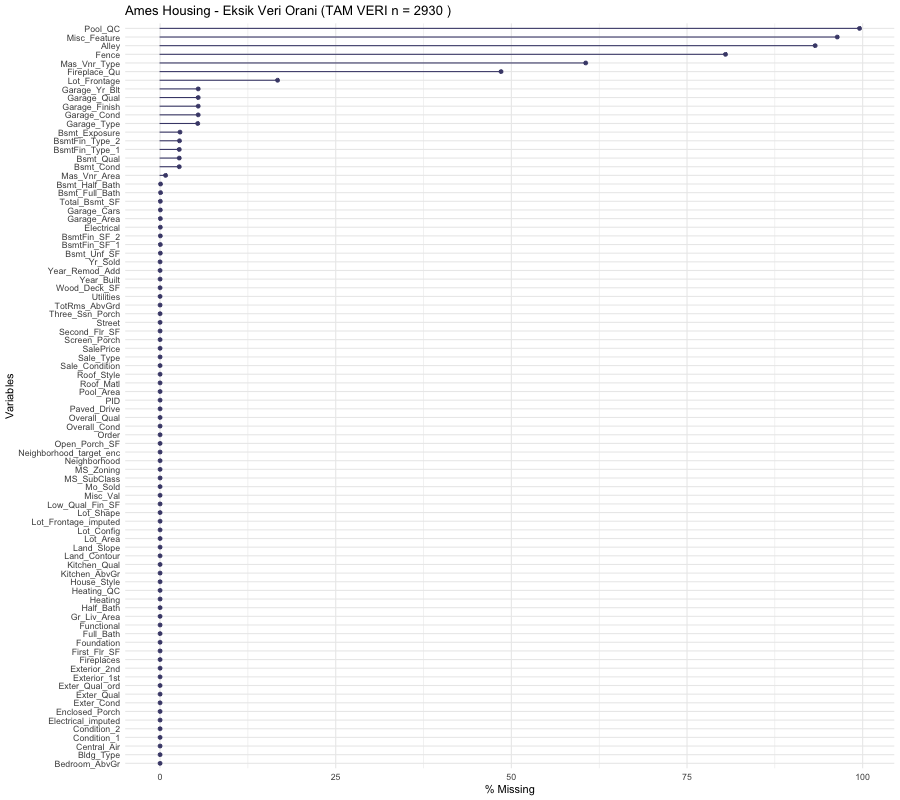

In [37]:
%%R -w 900 -h 800
gg_miss_var(ames_r, show_pct = TRUE) +
  labs(title = paste("Ames Housing - Eksik Veri Orani (TAM VERI n =", nrow(ames_r), ")"))

### 🧮 R 2 — Mean / Median / Mode Imputation: `Lot_Frontage` ve `Electrical`

**Ne yapıyoruz?**
Python 3'ün R karşılığı: `dplyr::mutate` + `coalesce` ile medyan/mod doldurma.

In [67]:
%%R
lot_frontage_median <- median(ames_r$Lot_Frontage, na.rm = TRUE)
electrical_mode <- names(sort(table(ames_r$Electrical), decreasing = TRUE))[1]

ames_r <- ames_r %>%
  mutate(
    Lot_Frontage_imputed = coalesce(Lot_Frontage, lot_frontage_median),
    Electrical_imputed = coalesce(Electrical, electrical_mode)
  )

cat("Lot_Frontage medyani:", lot_frontage_median, "\n")
cat("Std once:", sd(ames_r$Lot_Frontage, na.rm = TRUE), " | Std sonra:", sd(ames_r$Lot_Frontage_imputed), "\n")
cat("Electrical modu:", electrical_mode, "\n")

Lot_Frontage medyani: 68 
Std once: 23.36533  | Std sonra: 21.32642 
Electrical modu: SBrkr 


### 🔗 R 3 — KNN Imputation: `VIM::kNN` (Diabetes)

**Ne yapıyoruz?**
Python 5-6'nın R karşılığı: önce fizyolojik olarak imkansız sıfırları `NA`'ya çeviriyoruz, sonra `VIM::kNN` ile ($k=5$) dolduruyoruz — `VIM` içeride otomatik olarak ölçekleme uygular.

In [68]:
%%R
zero_as_na_cols <- c("Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI")
diabetes_r <- diabetes_r %>%
  mutate(across(all_of(zero_as_na_cols), ~ na_if(., 0)))

cat("Sifirdan NA'ya cevrilen sutunlardaki eksik sayilari:\n")
print(colSums(is.na(diabetes_r[zero_as_na_cols])))

diabetes_knn_r <- kNN(diabetes_r, variable = zero_as_na_cols, k = 5, imp_var = FALSE)
cat("\nKNN Imputation sonrasi kalan NA sayisi:", sum(is.na(diabetes_knn_r[zero_as_na_cols])), "\n")

Sifirdan NA'ya cevrilen sutunlardaki eksik sayilari:
      Glucose BloodPressure SkinThickness       Insulin           BMI 
            5            35           227           374            11 

KNN Imputation sonrasi kalan NA sayisi: 0 


### 🔁 R 4 — MICE: Çok Değişkenli Imputation ve Yöntem Karşılaştırması (Diabetes)

**Ne yapıyoruz?**
Python 7'nin R karşılığı — ama bu sefer yöntemin **orijinal referans paketiyle**: `mice()`, `Insulin`'i diğer tüm sütunları kullanan bir regresyon zinciriyle (varsayılan olarak `pmm` — predictive mean matching) 5 kez (`m=5`) dolduruyor; `complete()` ile ilk tamamlanmış veri setini alıp gözlenen dağılımla karşılaştırıyoruz.

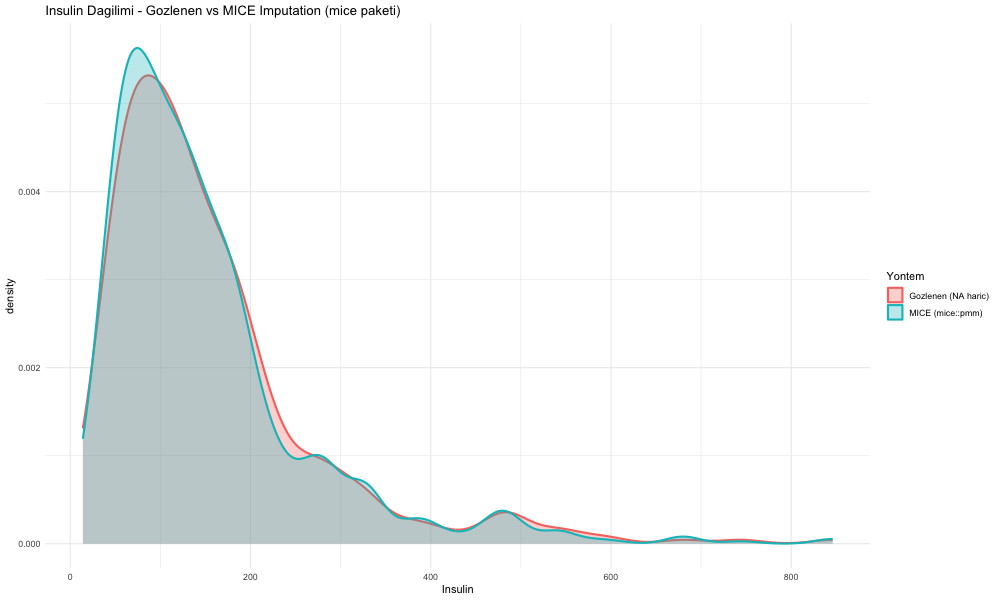

In [69]:
%%R -w 1000 -h 600
mice_fit <- mice(diabetes_r[zero_as_na_cols], m = 5, method = "pmm", seed = 42, printFlag = FALSE)
diabetes_mice_r <- complete(mice_fit, 1)

compare_df <- bind_rows(
  tibble(Insulin = diabetes_r$Insulin[!is.na(diabetes_r$Insulin)], Yontem = "Gozlenen (NA haric)"),
  tibble(Insulin = diabetes_mice_r$Insulin, Yontem = "MICE (mice::pmm)")
)

ggplot(compare_df, aes(x = Insulin, fill = Yontem, color = Yontem)) +
  geom_density(alpha = 0.3, linewidth = 1) +
  theme_minimal() +
  ggtitle("Insulin Dagilimi - Gozlenen vs MICE Imputation (mice paketi)")

## 🅱️ R — Aykırı Değer, Encoding, Ölçekleme, Özellik Mühendisliği

### 📏 R 5 — IQR ve Z-Score Aykırı Değer Tespiti (Wine, TAM VERİ)

**Ne yapıyoruz?**
Python 8-9'un R karşılığı: `total_sulfur_dioxide` için IQR sınırlarını hesaplayıp boxplot ile gösteriyoruz, ardından z-score tabanlı bir bayrak sütunu ekliyoruz.

IQR sinirlari: [ -38 , 122 ]  | IQR aykiri sayisi: 55  | Z-score aykiri sayisi: 15 


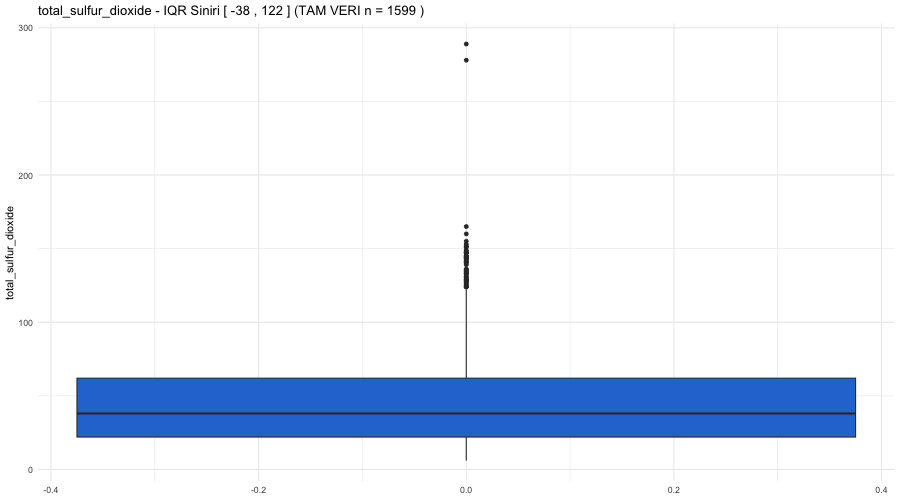

In [70]:
%%R -w 900 -h 500
q1 <- quantile(wine_r$total_sulfur_dioxide, 0.25)
q3 <- quantile(wine_r$total_sulfur_dioxide, 0.75)
iqr_val <- q3 - q1
lower <- q1 - 1.5 * iqr_val
upper <- q3 + 1.5 * iqr_val

wine_r <- wine_r %>%
  mutate(
    is_outlier_iqr = total_sulfur_dioxide < lower | total_sulfur_dioxide > upper,
    z_score = as.numeric(scale(total_sulfur_dioxide)),
    is_outlier_z = abs(z_score) > 3
  )

cat("IQR sinirlari: [", lower, ",", upper, "]  | IQR aykiri sayisi:", sum(wine_r$is_outlier_iqr),
    " | Z-score aykiri sayisi:", sum(wine_r$is_outlier_z), "\n")

ggplot(wine_r, aes(y = total_sulfur_dioxide)) +
  geom_boxplot(fill = "#2a78d6") +
  theme_minimal() +
  ggtitle(paste("total_sulfur_dioxide - IQR Siniri [", round(lower,1), ",", round(upper,1), "] (TAM VERI n =", nrow(wine_r), ")"))

### 🏷️ R 6 — One-Hot, Ordinal ve Target Encoding (Ames)

**Ne yapıyoruz?**
Python 11-14'ün R karşılığı: `model.matrix` ile One-Hot, `factor(..., ordered=TRUE)` ile Ordinal, `dplyr::group_by` + `summarise` + `left_join` ile Target (Mean) Encoding — R'ın temel veri işleme fonksiyonlarıyla, ek bir paket gerekmeden.

In [71]:
%%R
# One-Hot (MS_Zoning) - k-1 sutun (intercept haric, dummy tuzagindan kacinmak icin)
ohe_matrix <- model.matrix(~ MS_Zoning, data = ames_r)[, -1]
cat("One-Hot sutun sayisi (MS_Zoning, referans kategori haric):", ncol(ohe_matrix), "\n\n")

# Ordinal (Exter_Qual)
quality_levels <- c("Po", "Fa", "TA", "Gd", "Ex")
ames_r <- ames_r %>%
  mutate(Exter_Qual_ord = as.integer(factor(Exter_Qual, levels = quality_levels, ordered = TRUE)))
cat("Exter_Qual ordinal kod ornegi:\n")
print(head(ames_r %>% select(Exter_Qual, Exter_Qual_ord), 5))

# Target (Mean) Encoding (Neighborhood -> SalePrice), smoothing ile
global_mean <- mean(ames_r$SalePrice)
m_smooth <- 10
neighborhood_stats <- ames_r %>%
  group_by(Neighborhood) %>%
  summarise(n = n(), mean_price = mean(SalePrice)) %>%
  mutate(smoothed_mean = (n * mean_price + m_smooth * global_mean) / (n + m_smooth))

ames_r <- ames_r %>% left_join(neighborhood_stats %>% select(Neighborhood, smoothed_mean), by = "Neighborhood") %>%
  rename(Neighborhood_target_enc = smoothed_mean)

cat("\nEn az gozlemli 5 mahallede smoothing etkisi:\n")
print(neighborhood_stats %>% arrange(n) %>% head(5))

One-Hot sutun sayisi (MS_Zoning, referans kategori haric): 6 

Exter_Qual ordinal kod ornegi:
  Exter_Qual Exter_Qual_ord
0         TA              3
1         TA              3
2         TA              3
3         Gd              4
4         TA              3

En az gozlemli 5 mahallede smoothing etkisi:
# A tibble: 5 × 4
  Neighborhood     n mean_price smoothed_mean
  <chr>        <int>      <dbl>         <dbl>
1 Landmrk          1    137000        176815.
2 GrnHill          2    280000        197330.
3 Greens           8    193531.       186456.
4 Blueste         10    143590        162193.
5 NPkVill         23    140711.       152858.


### ⚖️ R 7 — Ölçekleme Karşılaştırması: `scale()` vs Min-Max vs Log

**Ne yapıyoruz?**
Python 16-17'nin R karşılığı: `scale()` ile standardization, elle yazılmış bir min-max fonksiyonuyla normalization, `log1p()` ile log dönüşümü — üçünü tek bir grid'de karşılaştırıyoruz.

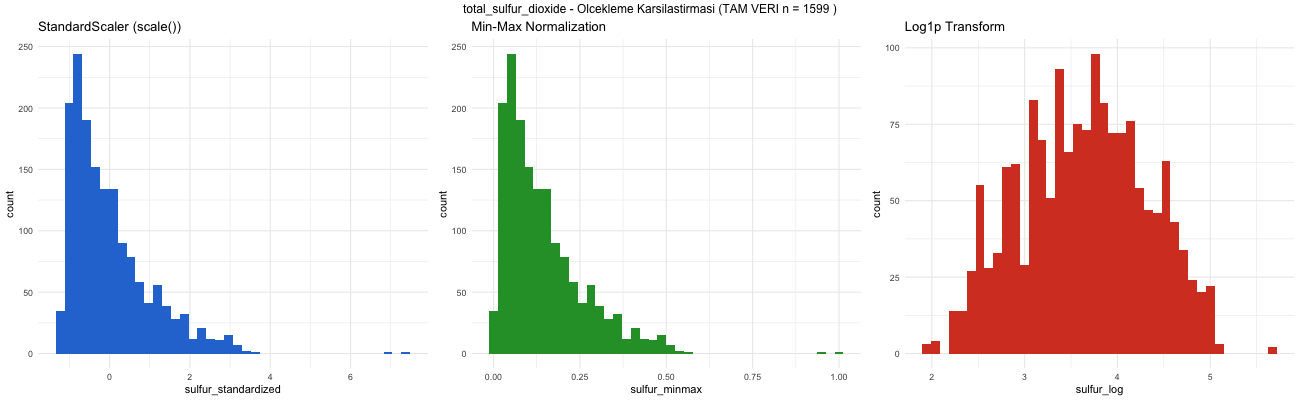

In [72]:
%%R -w 1300 -h 400
min_max <- function(x) (x - min(x)) / (max(x) - min(x))

wine_r <- wine_r %>%
  mutate(
    sulfur_standardized = as.numeric(scale(total_sulfur_dioxide)),
    sulfur_minmax = min_max(total_sulfur_dioxide),
    sulfur_log = log1p(total_sulfur_dioxide)
  )

p1 <- ggplot(wine_r, aes(x = sulfur_standardized)) + geom_histogram(bins = 40, fill = "#2a78d6") +
  theme_minimal() + ggtitle("StandardScaler (scale())")
p2 <- ggplot(wine_r, aes(x = sulfur_minmax)) + geom_histogram(bins = 40, fill = "#2a9d34") +
  theme_minimal() + ggtitle("Min-Max Normalization")
p3 <- ggplot(wine_r, aes(x = sulfur_log)) + geom_histogram(bins = 40, fill = "#d6432a") +
  theme_minimal() + ggtitle("Log1p Transform")

gridExtra::grid.arrange(p1, p2, p3, ncol = 3,
                         top = paste("total_sulfur_dioxide - Olcekleme Karsilastirmasi (TAM VERI n =", nrow(wine_r), ")"))

### 🛠️ R 8 — Özellik Mühendisliği: `Total_SF`, `House_Age` ve Binning (Ames + Wine)

**Ne yapıyoruz?**
Python 18-19'un R karşılığı: `dplyr::mutate` ile türetilmiş özellikler, `cut()` (eşit genişlik) ve `ntile()`/`cut(breaks=quantile(...))` (eşit frekans) ile binning.

In [73]:
%%R
ames_r <- ames_r %>%
  mutate(
    Total_SF = First_Flr_SF + Second_Flr_SF + Total_Bsmt_SF,
    House_Age = Yr_Sold - Year_Built
  )

wine_r <- wine_r %>%
  mutate(
    alcohol_bin_width = cut(alcohol, breaks = 4),
    alcohol_bin_freq = cut(alcohol, breaks = quantile(alcohol, probs = seq(0, 1, 0.25)), include.lowest = TRUE)
  )

cat("Total_SF ile SalePrice korelasyonu:", cor(ames_r$Total_SF, ames_r$SalePrice), "\n")
cat("House_Age ile SalePrice korelasyonu:", cor(ames_r$House_Age, ames_r$SalePrice), "\n\n")
cat("Esit-frekans alkol dilimleri:\n")
print(table(wine_r$alcohol_bin_freq))

Total_SF ile SalePrice korelasyonu: NA 
House_Age ile SalePrice korelasyonu: -0.5589068 

Esit-frekans alkol dilimleri:

  [8.4,9.5]  (9.5,10.2] (10.2,11.1] (11.1,14.9] 
        436         406         377         380 


---
# 🗄️ SQL Uygulaması (DuckDB): Ön İşlemeyi Tek Sorguda Yapmak

Birçok ön işleme adımı aslında saf SQL ile de yapılabilir — özellikle veri bir veri ambarında (data warehouse) yaşıyorsa, Python'a hiç çekmeden `COALESCE`, pencere fonksiyonları (`window functions`) ve `CASE WHEN` ile imputation, aykırı değer tespiti, encoding ve ölçeklemenin çoğunu tek bir sorguda yapmak mümkündür — iş hayatında sık karşılaşılan bir senaryo.

In [74]:
import duckdb
con = duckdb.connect()
con.register('ames_tbl', ames_raw_for_r)
con.register('diabetes_tbl', diabetes)
con.register('wine_tbl', wine_raw_for_r)
print('DuckDB hazir ✓ (ames_tbl, diabetes_tbl, wine_tbl tablolari kayitli - HAM veriyle)')

DuckDB hazir ✓ (ames_tbl, diabetes_tbl, wine_tbl tablolari kayitli - HAM veriyle)


### 📊 SQL 1 — `SUMMARIZE`: Tüm Sütunların Eksik Yüzdesini Tek Komutla Görmek

**Ne yapıyoruz?**
DuckDB'nin yerleşik `SUMMARIZE` komutu, bir tablodaki **her sütun** için min/max/ortalama/çeyrekler ile birlikte `null_percentage`'ı otomatik hesaplar — Python 2'deki manuel `isna().sum()` bar chart'ının SQL'deki tek satırlık karşılığı.

In [75]:
summary_df = con.execute("SUMMARIZE ames_tbl").df()
top_missing = summary_df[['column_name', 'null_percentage']].sort_values('null_percentage', ascending=False).head(10)
print(top_missing.to_string(index=False))

  column_name  null_percentage
      Pool_QC            99.56
 Misc_Feature            96.38
        Alley            93.24
        Fence            80.48
 Mas_Vnr_Type            60.58
 Fireplace_Qu            48.53
 Lot_Frontage            16.72
  Garage_Cond             5.43
Garage_Finish             5.43
Garage_Yr_Blt             5.43


### 🧮 SQL 2 — `COALESCE` + `MEDIAN()`: Imputation Tek Satırda

**Ne yapıyoruz?**
Python 3'ün SQL karşılığı: `COALESCE(sutun, alt_sorgu)` ile eksik değeri, aynı sütunun medyanıyla dolduruyoruz — DuckDB'nin yerleşik `MEDIAN()` fonksiyonuyla.

In [76]:
sql_impute = '''
SELECT
    Lot_Frontage,
    COALESCE(Lot_Frontage, (SELECT MEDIAN(Lot_Frontage) FROM ames_tbl)) AS Lot_Frontage_imputed
FROM ames_tbl
WHERE Lot_Frontage IS NULL
LIMIT 5;
'''

print(con.execute(sql_impute).df())

   Lot_Frontage  Lot_Frontage_imputed
0           NaN                  68.0
1           NaN                  68.0
2           NaN                  68.0
3           NaN                  68.0
4           NaN                  68.0


### 📏 SQL 3 — IQR ile Aykırı Değer Tespiti: Pencere Fonksiyonu Gerekmeden `PERCENTILE_CONT`

**Ne yapıyoruz?**
Python 8'in SQL karşılığı: `PERCENTILE_CONT(...) WITHIN GROUP (ORDER BY ...)` ile $Q_1$/$Q_3$'ü hesaplayıp, bir CTE (`WITH`) içinde tüm satırlara `CROSS JOIN` ile bağlayarak IQR sınırlarını ve aykırı değer bayrağını tek sorguda üretiyoruz.

In [77]:
sql_iqr = '''
WITH stats AS (
    SELECT
        PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY total_sulfur_dioxide) AS q1,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY total_sulfur_dioxide) AS q3
    FROM wine_tbl
)
SELECT
    COUNT(*) AS toplam_satir,
    SUM(CASE WHEN total_sulfur_dioxide < q1 - 1.5*(q3-q1) OR total_sulfur_dioxide > q3 + 1.5*(q3-q1) THEN 1 ELSE 0 END) AS aykiri_sayisi,
    q1, q3, (q3 - q1) AS iqr
FROM wine_tbl CROSS JOIN stats
GROUP BY q1, q3;
'''

print(con.execute(sql_iqr).df())

   toplam_satir  aykiri_sayisi    q1    q3   iqr
0          1599           55.0  22.0  62.0  40.0


### 📐 SQL 4 — Z-Score: Pencere Fonksiyonu (`OVER()`) ile Tüm Veriye Tek Geçişte

**Ne yapıyoruz?**
Python 9'un SQL karşılığı: `AVG() OVER()` ve `STDDEV_POP() OVER()` pencere fonksiyonlarıyla, alt sorguya/self-join'e gerek kalmadan her satır için z-score hesaplıyoruz.

In [78]:
sql_zscore = '''
SELECT
    total_sulfur_dioxide,
    (total_sulfur_dioxide - AVG(total_sulfur_dioxide) OVER()) / STDDEV_POP(total_sulfur_dioxide) OVER() AS z_score
FROM wine_tbl
QUALIFY ABS(z_score) > 3
ORDER BY z_score DESC;
'''

z_outliers = con.execute(sql_zscore).df()
print(f"Z-score ile bulunan aykiri deger sayisi: {len(z_outliers)}")
z_outliers.head(5)

Z-score ile bulunan aykiri deger sayisi: 15


,total_sulfur_dioxide,z_score
0,289.0,7.375154
1,278.0,7.040655
2,165.0,3.604442
3,160.0,3.452397
4,155.0,3.300352


### 🏷️ SQL 5 — One-Hot ve Ordinal Encoding: `CASE WHEN` ile Elle Pivot

**Ne yapıyoruz?**
Python 11 ve 13'ün SQL karşılığı: One-Hot için her kategoriye bir `CASE WHEN ... THEN 1 ELSE 0 END` sütunu, Ordinal için kalite skalasını sayıya çeviren tek bir `CASE WHEN` ifadesi yazıyoruz — SQL'de yerleşik bir encoder olmadığı için bu iş elle yapılır.

In [79]:
sql_encoding = '''
SELECT
    MS_Zoning,
    CASE WHEN MS_Zoning = 'RL' THEN 1 ELSE 0 END AS MS_Zoning_RL,
    CASE WHEN MS_Zoning = 'RM' THEN 1 ELSE 0 END AS MS_Zoning_RM,
    CASE WHEN MS_Zoning = 'FV' THEN 1 ELSE 0 END AS MS_Zoning_FV,
    Exter_Qual,
    CASE Exter_Qual
        WHEN 'Po' THEN 1 WHEN 'Fa' THEN 2 WHEN 'TA' THEN 3 WHEN 'Gd' THEN 4 WHEN 'Ex' THEN 5
    END AS Exter_Qual_ordinal
FROM ames_tbl
LIMIT 5;
'''

print(con.execute(sql_encoding).df())

  MS_Zoning  MS_Zoning_RL  MS_Zoning_RM  MS_Zoning_FV Exter_Qual  \
0        RL             1             0             0         TA   
1        RH             0             0             0         TA   
2        RL             1             0             0         TA   
3        RL             1             0             0         Gd   
4        RL             1             0             0         TA   

   Exter_Qual_ordinal  
0                   3  
1                   3  
2                   3  
3                   4  
4                   3  


### 🎯 SQL 6 — Target Encoding: `AVG() OVER (PARTITION BY ...)` ile Tek Satırda

**Ne yapıyoruz?**
Python 14'ün SQL karşılığı — ve aslında en zarif hâli: `PARTITION BY Neighborhood` ile pencere fonksiyonu, her satıra **kendi mahallesinin ortalama fiyatını** `GROUP BY`/`JOIN` yazmaya gerek kalmadan tek satırda ekliyor.

In [80]:
sql_target_enc = '''
SELECT
    Neighborhood,
    SalePrice,
    AVG(SalePrice) OVER (PARTITION BY Neighborhood) AS Neighborhood_target_enc,
    COUNT(*) OVER (PARTITION BY Neighborhood) AS Neighborhood_n
FROM ames_tbl
ORDER BY Neighborhood_target_enc DESC
LIMIT 8;
'''

print(con.execute(sql_target_enc).df().round(0))

  Neighborhood  SalePrice  Neighborhood_target_enc  Neighborhood_n
0      NoRidge     333168                 330319.0              71
1      NoRidge     260400                 330319.0              71
2      NoRidge     325000                 330319.0              71
3      NoRidge     410000                 330319.0              71
4      NoRidge     355000                 330319.0              71
5      NoRidge     221000                 330319.0              71
6      NoRidge     290000                 330319.0              71
7      NoRidge     190000                 330319.0              71


### 📉 SQL 7 — Log Transform ve Çarpıklık: `LN()` ile Önce/Sonra

**Ne yapıyoruz?**
Python 17'nin SQL karşılığı: `LN(1 + SalePrice)` ile log dönüşümü uygulayıp, çarpıklığı üçüncü moment formülüyle (`AVG(POWER(z, 3))`, $z$=standardize edilmiş değer) SQL içinde doğrudan hesaplıyoruz — hiçbir satırı Python'a çekmeden.

In [81]:
sql_skew = '''
WITH base AS (
    SELECT SalePrice, LN(1 + SalePrice) AS log_price FROM ames_tbl
), moments AS (
    SELECT
        AVG(SalePrice) AS m_raw, STDDEV_POP(SalePrice) AS s_raw,
        AVG(log_price) AS m_log, STDDEV_POP(log_price) AS s_log
    FROM base
)
SELECT
    AVG(POWER((b.SalePrice - m.m_raw) / m.s_raw, 3)) AS skew_before,
    AVG(POWER((b.log_price - m.m_log) / m.s_log, 3)) AS skew_after
FROM base b CROSS JOIN moments m;
'''

print(con.execute(sql_skew).df().round(3))
print("-> log donusumu sonrasi carpiklik belirgin sekilde 0'a yaklasti (Python 17 ile tutarli).")

   skew_before  skew_after
0        1.743      -0.015
-> log donusumu sonrasi carpiklik belirgin sekilde 0'a yaklasti (Python 17 ile tutarli).


---
## ✏️ Egzersizler

Bu bölümdeki egzersizlerin **çözümü verilmemiştir** — amaç, yukarıdaki adımları kendi ellerinle uygulaman. `ames`, `diabetes`/`diabetes_clean`, `wine` (Python) / `ames_r`, `diabetes_r`, `wine_r` (R) / `ames_tbl`, `diabetes_tbl`, `wine_tbl` (SQL) değişkenleri/tabloları zaten yukarıda hazır, doğrudan kullanabilirsin.

### **E1 (Python) — Eksik Veri Stratejisi Seçimi.**
Ames veri setinde `Garage_Cars` (1 eksik) ve `Mas_Vnr_Area` (23 eksik) sütunlarını uygun bir yöntemle doldur (mean/median, KNN veya MICE — Bölüm 3'teki karar haritasına bakarak seç). Hangi yöntemi neden seçtiğini bir markdown hücresinde kısaca gerekçelendir.


 ==== Egzersiz 1: Eksik Veri Seçimi ====
Garage_Cars eksik olan satır sayısı: 1


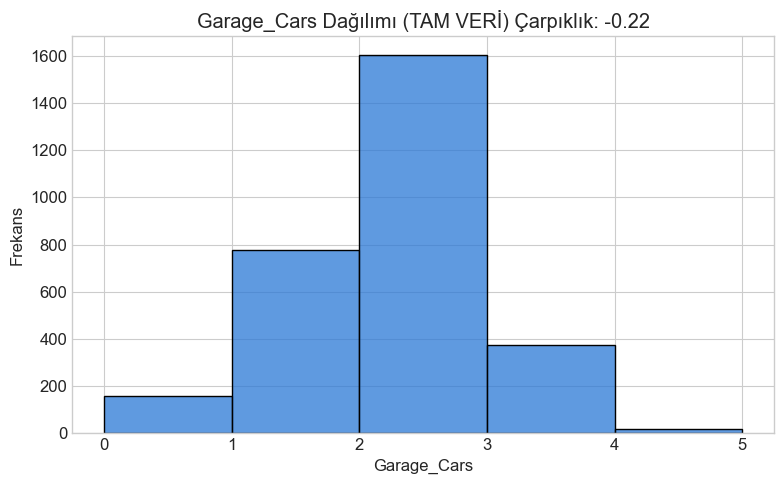

Eksik Garage_Cars ile diğer sayısal değişkenler arasındaki korelasyonlar:
             Garage_Area  Garage_Cars
Garage_Area         1.00         0.89
Garage_Cars         0.89         1.00
Garage_Cars eksik verileri median ile dolduruldu: 2.0
Std öncesi Garage_Cars: 0.76 | Std sonrası Garage_Cars_imputed: 0.76
Mas_Vnr_Area eksik olan satır sayısı: 23


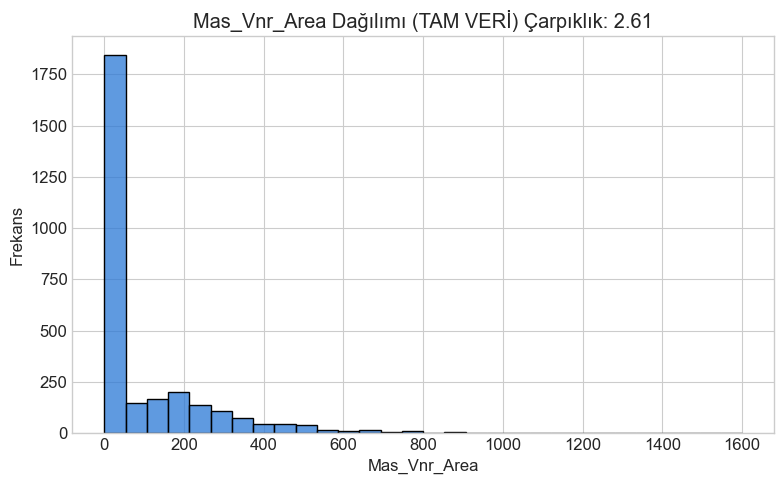

Eksik Mas_Vnr_Area ile diğer sayısal değişkenler arasındaki korelasyonlar:
               Mas_Vnr_Area  SalePrice  Gr_Liv_Area  Total_Bsmt_SF  \
Mas_Vnr_Area           1.00       0.51         0.40           0.40   
SalePrice              0.51       1.00         0.71           0.63   
Gr_Liv_Area            0.40       0.71         1.00           0.44   
Total_Bsmt_SF          0.40       0.63         0.44           1.00   
Garage_Area            0.37       0.64         0.48           0.49   

               Garage_Area  
Mas_Vnr_Area          0.37  
SalePrice             0.64  
Gr_Liv_Area           0.48  
Total_Bsmt_SF         0.49  
Garage_Area           1.00  
Mas_Vnr_Area eksik verileri mean ile dolduruldu: 101.90
Std öncesi Mas_Vnr_Area: 179.11 | Std sonrası Mas_Vnr_Area_imputed: 178.41


In [108]:
print("\n ==== Egzersiz 1: Eksik Veri Seçimi ====")

# Veri setinde eksikliği gidermek için önce ne kadar veri eksik anlamalıyız
# Sonrasında veri nasıl dağılmış bakmalıyız.
# Sonrasında öbür verilerle ilişkili olup olmadığını anlamalıyız.

# Garage_Cars için bakalım

# 1. Kaç satırda Garage_Cars eksik?
garage_cars_missing = ames_raw_for_r[ames_raw_for_r['Garage_Cars'].isna()]
print(f"Garage_Cars eksik olan satır sayısı: {len(garage_cars_missing)}")

# 2. Veri dağılımına bakalım
plt.figure(figsize=(8, 5))
sns.histplot(ames_raw_for_r['Garage_Cars'].dropna(), bins=range(0, 6), color='#2a78d6', kde=False)
plt.title(f'Garage_Cars Dağılımı (TAM VERİ) Çarpıklık: {ames_raw_for_r["Garage_Cars"].skew():.2f}')
plt.xlabel('Garage_Cars')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

# 3. Eksik verilerin diğer değişkenlerle ilişkisine bakalım
numerical_cols = ['Garage_Area', 'Garage_Cars']
correlations = ames_raw_for_r[numerical_cols].corr()
print("Eksik Garage_Cars ile diğer sayısal değişkenler arasındaki korelasyonlar:")
print(correlations.round(2))


# Garage_Cars 1 tanecik sütun boş, çarpıklık olarak normale yakın ve öbür değişkenle güçlü korelasyona sahip. Az olduğu için çok etki etmeyecek. Bu yüzden eksik veriyi ortalama veya medyan ile doldurabiliriz.
median_garage_cars = ames_raw_for_r['Garage_Cars'].median()
ames_raw_for_r['Garage_Cars_imputed'] = ames_raw_for_r['Garage_Cars'].fillna(median_garage_cars)
print(f"Garage_Cars eksik verileri median ile dolduruldu: {median_garage_cars}")

print(f"Std öncesi Garage_Cars: {ames_raw_for_r['Garage_Cars'].std():.2f} | Std sonrası Garage_Cars_imputed: {ames_raw_for_r['Garage_Cars_imputed'].std():.2f}")


# Mas_Vnr_Area için bakalım

# 1. Kaç satırda Mas_Vnr_Area eksik?
mas_vnr_area_missing = ames_raw_for_r[ames_raw_for_r['Mas_Vnr_Area'].isna()]
print(f"Mas_Vnr_Area eksik olan satır sayısı: {len(mas_vnr_area_missing)}")

# 2. Veri dağılımına bakalım
plt.figure(figsize=(8, 5))
sns.histplot(ames_raw_for_r['Mas_Vnr_Area'].dropna(), bins=30, color='#2a78d6', kde=False)
plt.title(f'Mas_Vnr_Area Dağılımı (TAM VERİ) Çarpıklık: {ames_raw_for_r["Mas_Vnr_Area"].skew():.2f}')
plt.xlabel('Mas_Vnr_Area')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

# 3. Eksik verilerin diğer değişkenlerle ilişkisine bakalım
numerical_cols = ['Mas_Vnr_Area', 'SalePrice', 'Gr_Liv_Area', 'Total_Bsmt_SF', 'Garage_Area']
correlations = ames_raw_for_r[numerical_cols].corr()
print("Eksik Mas_Vnr_Area ile diğer sayısal değişkenler arasındaki korelasyonlar:")
print(correlations.round(2))

# Mas_Vnr_Area için 23 satır boş, çarpıklık olarak aşırı sağa çarpık ve öbür değişkenle ortalama bir korelasyona sahip. Ama NaN verisi %1'den az olduğu için eksik veriyi ortalama veya mean ile doldurabiliriz.
mean_mas_vnr_area = ames_raw_for_r['Mas_Vnr_Area'].mean()
ames_raw_for_r['Mas_Vnr_Area_imputed'] = ames_raw_for_r['Mas_Vnr_Area'].fillna(mean_mas_vnr_area)
print(f"Mas_Vnr_Area eksik verileri mean ile dolduruldu: {mean_mas_vnr_area:.2f}")
print(f"Std öncesi Mas_Vnr_Area: {ames_raw_for_r['Mas_Vnr_Area'].std():.2f} | Std sonrası Mas_Vnr_Area_imputed: {ames_raw_for_r['Mas_Vnr_Area_imputed'].std():.2f}")


### **E2 (Python) — Aykırı Değer Yöntemi Karşılaştırması.**
Wine veri setinde `residual_sugar` sütunu için hem IQR (1.5×) hem de Modified Z-Score (Bölüm 4.1-4.2) ile aykırı değerleri bul. İki yöntemin bulduğu aykırı değer sayısı ve kümesi ne kadar örtüşüyor? `residual_sugar`'ın dağılım şekline (çarpıklığına) bakarak hangi yöntemi tercih edeceğini gerekçelendir.


 ==== Egzersiz 2: Aykırı Değer Yöntemi Karşılaştırması ====
Residual_Sugar IQR yöntemi ile aykırı değer sayısı: 155
Residual_Sugar Modified Z-Score yöntemi ile aykırı değer sayısı: 150


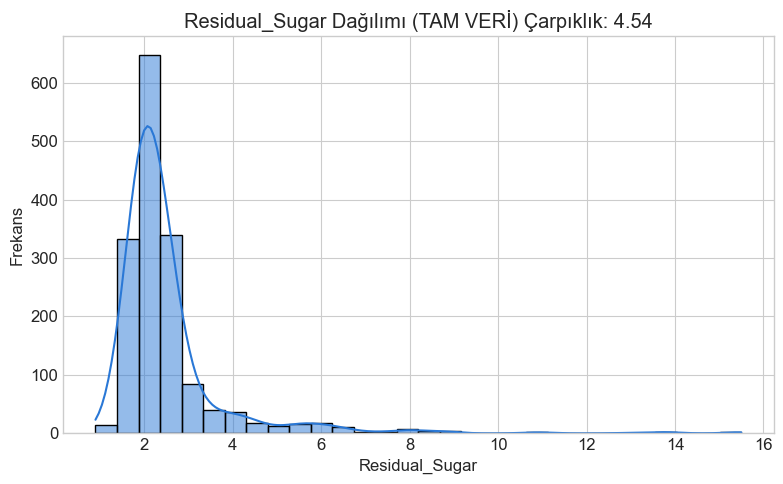

In [111]:
print("\n ==== Egzersiz 2: Aykırı Değer Yöntemi Karşılaştırması ====")

# IQR yöntemi ile aykırı değerleri tespit edelim
def iqr_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return (df[column] < lower_bound) | (df[column] > upper_bound)

# Modified Z-Score yöntemi ile aykırı değerleri tespit edelim
def modified_z_score_outliers(df, column):
    median = df[column].median()
    mad = np.median(np.abs(df[column] - median))
    modified_z_scores = 0.6745 * (df[column] - median) / mad
    return np.abs(modified_z_scores) > 3.5

residual_sugar_outliers_iqr = iqr_outliers(wine_raw_for_r, 'residual_sugar')
residual_sugar_outliers_mz = modified_z_score_outliers(wine_raw_for_r, 'residual_sugar')

print(f"Residual_Sugar IQR yöntemi ile aykırı değer sayısı: {residual_sugar_outliers_iqr.sum()}")
print(f"Residual_Sugar Modified Z-Score yöntemi ile aykırı değer sayısı: {residual_sugar_outliers_mz.sum()}")

# Dağılım şekline bakalım
plt.figure(figsize=(8, 5))
sns.histplot(wine_raw_for_r['residual_sugar'], bins=30, color='#2a78d6', kde=True)
plt.title(f'Residual_Sugar Dağılımı (TAM VERİ) Çarpıklık: {wine_raw_for_r["residual_sugar"].skew():.2f}')
plt.xlabel('Residual_Sugar')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

# Genel olarak çarpıklık fazla olduğu için (4.54) en mantıklı olarak IQR yöntemi ile aykırı değerleri tespit etmek daha uygun olacaktır. Modified Z-Score yöntemi, çarpık dağılımlarda daha fazla aykırı değer tespit edebilir ve bu da model performansını olumsuz etkileyebilir.
# Ayrıca Modified Z-Score normale yakın dağılımlarda daha iyi çalışır, çarpık dağılımlarda ise IQR yöntemi daha güvenilirdir. Bu nedenle, residual_sugar için IQR yöntemi tercih edilmelidir.

### **E3 (Python) — Encoding Uygulaması.**
Ames'te `Bsmt_Qual` sütununu (Python 4'te `'None'` ile doldurulmuştu, artık `Po/Fa/TA/Gd/Ex/None` kategorileri var — `None`'ı sıranın en altına ekleyerek) Ordinal Encoding ile kodla. Ardından `Sale_Condition` sütununu One-Hot Encoding ile kodla ve kaç yeni sütun oluştuğunu yazdır.

In [127]:
print("\n ==== Egzersiz 3: Encoding Uygulaması ====")

# Bsmt_Qual None ile doldurulup Has_Bsmt eklenmişti
# Şimdi Ordinal Encoding ile Bsmt_Qual'u encode edelim

quality_order_bsmt = ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
ordinal_encoder_bsmt = OrdinalEncoder(categories=[quality_order_bsmt])
ames['Bsmt_Qual_ord'] = ordinal_encoder_bsmt.fit_transform(ames[['Bsmt_Qual']])
print("Bsmt_Qual Ordinal Encoding örnek (ilk 5 satır):")
print(ames[['Bsmt_Qual', 'Bsmt_Qual_ord']].head(5))

# Sale_Condition için One-Hot Encoding uygulayalım (pd.get_dummies veya sklearn OneHotEncoder kullanılabilir)
# pd.get_dummies ile örnek:
sale_condition_ohe = pd.get_dummies(ames['Sale_Condition'], prefix='Sale_Condition', drop_first=True)
ames = pd.concat([ames, sale_condition_ohe], axis=1)
print(f"pd.get_dummies (drop_first= True -> {sale_condition_ohe.shape[1]})")
print(sale_condition_ohe.columns.tolist())

# One-Hot Encoder
ohe = OneHotEncoder(drop='first', sparse_output=False)
sale_condition_ohe_sklearn = ohe.fit_transform(ames[['Sale_Condition']])
sale_condition_ohe_df = pd.DataFrame(sale_condition_ohe_sklearn, columns=ohe.get_feature_names_out(['Sale_Condition']))
ames = pd.concat([ames, sale_condition_ohe_df], axis=1)
print(f"sklearn OneHotEncoder (drop='first') -> {sale_condition_ohe_df.shape[1]})")
print(sale_condition_ohe_df.columns.tolist())


 ==== Egzersiz 3: Encoding Uygulaması ====
Bsmt_Qual Ordinal Encoding örnek (ilk 5 satır):
  Bsmt_Qual  Bsmt_Qual_ord
0        TA            3.0
1        TA            3.0
2        TA            3.0
3        TA            3.0
4        Gd            4.0
pd.get_dummies (drop_first= True -> 5)
['Sale_Condition_AdjLand', 'Sale_Condition_Alloca', 'Sale_Condition_Family', 'Sale_Condition_Normal', 'Sale_Condition_Partial']
sklearn OneHotEncoder (drop='first') -> 5)
['Sale_Condition_AdjLand', 'Sale_Condition_Alloca', 'Sale_Condition_Family', 'Sale_Condition_Normal', 'Sale_Condition_Partial']


### **E4 (R) — Ölçekleme Karşılaştırması.**
Wine veri setinde `alcohol` sütununu hem `scale()` (standardization) hem de elle yazacağın bir min-max fonksiyonuyla ölçekle (R 7'deki gibi). İki dağılımı `ggplot2` ile yan yana histogram olarak çiz ve yorumla.


 ==== Egzersiz 4: Ölçekleme Karşılaştırması ====
alcohol StandardScaler (scale()) std: 1 
alcohol Min-Max Normalization std: 0.1639489 


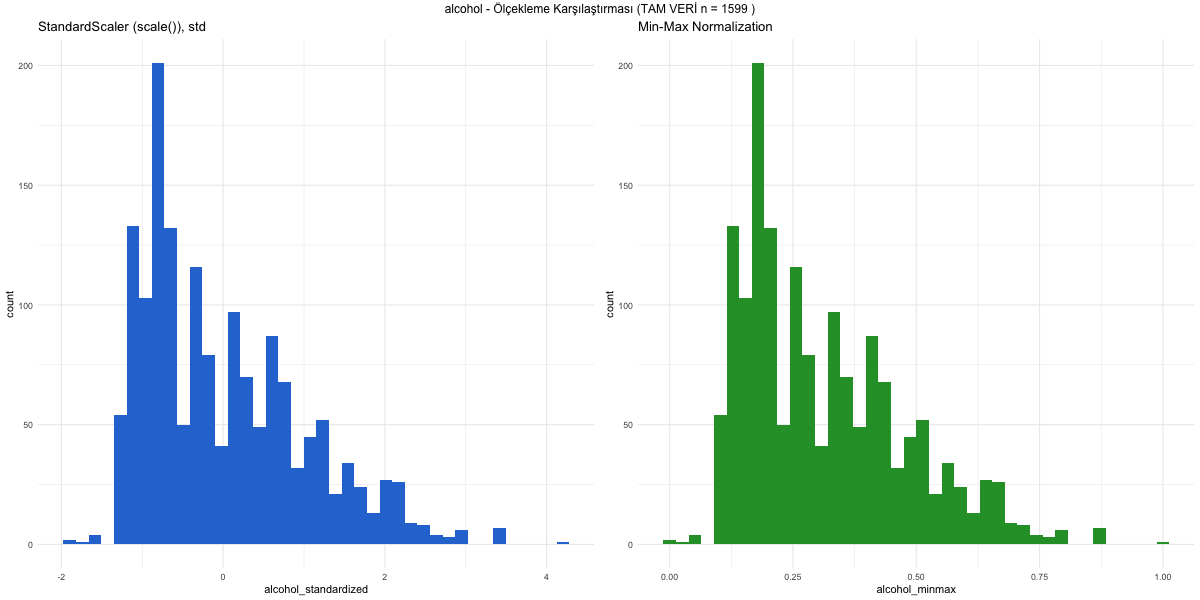

In [131]:
%%R -w 1200 -h 600
cat("\n ==== Egzersiz 4: Ölçekleme Karşılaştırması ====\n")


min_max_alc <- function(x) (x - min(x)) / (max(x) - min(x))

wine_r <- wine_r %>%
    mutate(
        alcohol_standardized = scale(alcohol),
        alcohol_minmax = min_max_alc(alcohol)
    )

std_standartization <- sd(wine_r$alcohol_standardized)
cat("alcohol StandardScaler (scale()) std:", std_standartization, "\n")
minmax_range <- sd(wine_r$alcohol_minmax)
cat("alcohol Min-Max Normalization std:", minmax_range, "\n")

p1 <- ggplot(wine_r, aes(x = alcohol_standardized)) + geom_histogram(bins = 40, fill = "#2a78d6") +
  theme_minimal() + ggtitle("StandardScaler (scale()), std")
p2 <- ggplot(wine_r, aes(x = alcohol_minmax)) + geom_histogram(bins = 40, fill = "#2a9d34") +
  theme_minimal() + ggtitle("Min-Max Normalization")

gridExtra::grid.arrange(p1, p2, ncol = 2,
                         top = paste("alcohol - Ölçekleme Karşılaştırması (TAM VERİ n =", nrow(wine_r), ")"))

### **E5 (SQL) — Gizli Eksik Veriyi SQL'de Doldurma.**
`diabetes_tbl` tablosunda `Glucose` sütunundaki `0` değerlerinin aslında eksik veri olduğunu biliyoruz (Python 5). SQL'de `CASE WHEN Glucose = 0 THEN NULL ELSE Glucose END` ile önce bunları `NULL`'a çevir, sonra `COALESCE` + `MEDIAN()` ile doldur — hepsini tek bir sorguda yap.

In [153]:
print("\n ==== Egzersiz 5: Gizli Eksik Veriyi SQL'de Doldurma ====")

diabetes = pd.read_csv('data/pima_diabetes.csv')

con.register('diabetes_egzersiz_tbl', diabetes)

sql_nan_sql = '''
SELECT
    Glucose,
    CASE WHEN Glucose = 0 THEN NULL ELSE Glucose END AS Glucose_imputed,
    COALESCE(
        Glucose_imputed, 
        (SELECT MEDIAN(CASE WHEN Glucose = 0 THEN NULL ELSE Glucose END) FROM diabetes_egzersiz_tbl)
    ) AS Glucose_final
FROM diabetes_egzersiz_tbl;
'''
print(con.execute(sql_nan_sql).df())

df_sql = con.execute(sql_nan_sql).df()


 ==== Egzersiz 5: Gizli Eksik Veriyi SQL'de Doldurma ====
     Glucose  Glucose_imputed  Glucose_final
0        148              148          148.0
1         85               85           85.0
2        183              183          183.0
3         89               89           89.0
4        137              137          137.0
..       ...              ...            ...
763      101              101          101.0
764      122              122          122.0
765      121              121          121.0
766      126              126          126.0
767       93               93           93.0

[768 rows x 3 columns]


### **E6 (Python — Sentez).**
Diabetes veri seti için kendi `Pipeline` + `ColumnTransformer`'ını kur: sayısal sütunlar için uygun bir imputer + scaler seç (gizli sıfırları önce `NaN`'a çevirmeyi unutma!), `Outcome`'u hedef değişken olarak kullanıp bir `LogisticRegression` ile `train_test_split` sonrası test doğruluğunu (accuracy) raporla. Bölüm 1'deki altın kurala (sadece train ile `fit`) dikkat et.

In [168]:
print("\n ==== Egzersiz 6: Pipeline + ColumnTransformer ile Modelleme ====")

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#print(diabetes.describe())

zero_as_na_cols_diabetes = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
diabetes_cleaned = diabetes.copy()
for col in zero_as_na_cols_diabetes:
    diabetes_cleaned[col] = diabetes_cleaned[col].replace(0, np.nan)
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
targeted_columns = ['Outcome']

# Tüm veriler zaten nümerik olduğu için tek bir transformer pipeline kullanabiliriz
# Bazı verilerde örneğin insülin gibi değerlerde eksiklik var önce onları doldurmak için imputer belirleyeceğiz.
numeric_transformer_diabetes = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),  
    ('scaler', StandardScaler()),
])

preprocessor_diabetes = ColumnTransformer(transformers=[
    ('num', numeric_transformer_diabetes, columns),
])
full_pipeline_diabetes = Pipeline(steps=[
    ('preprocessor', preprocessor_diabetes),
    ('model', LogisticRegression(max_iter=1000))
])

X = diabetes_cleaned[columns]
y = diabetes_cleaned[targeted_columns]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

full_pipeline_diabetes.fit(X_train, y_train.values.ravel())
test_accuracy = full_pipeline_diabetes.score(X_test, y_test)
print(f"Diabetes Logistic Regression test accuracy: {test_accuracy:.3f}")


 ==== Egzersiz 6: Pipeline + ColumnTransformer ile Modelleme ====
Diabetes Logistic Regression test accuracy: 0.766


---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Ames Housing — Data Documentation (De Cock, 2011, *Journal of Statistics Education*)](https://jse.amstat.org/v19n3/decock/DataDocumentation.txt) | Veri Seti | Kullanılan 1. veri seti — orijinal akademik yayın, sütun tanımları |
| [House Prices - Advanced Regression Techniques (Kaggle)](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques) | Veri Seti | Ames Housing'in Kaggle'daki yarışma sürümü |
| [Pima Indians Diabetes Database (Kaggle, uciml)](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database) / [UCI ML Repository](https://archive.ics.uci.edu/dataset/34/diabetes) | Veri Seti | Kullanılan 2. veri seti — gizlenmiş eksik veri (sıfır kodlu) klasiği |
| [Red Wine Quality (Kaggle, uciml, Cortez et al. 2009)](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009) | Veri Seti | Kullanılan 3. veri seti — tamamı sayısal, eksik değer yok |
| [scikit-learn — Imputation of Missing Values](https://scikit-learn.org/stable/modules/impute.html) | Resmi Dok. | `SimpleImputer`, `KNNImputer`, `IterativeImputer` API'leri |
| [scikit-learn — Preprocessing Data](https://scikit-learn.org/stable/modules/preprocessing.html) | Resmi Dok. | `StandardScaler`, `MinMaxScaler`, `RobustScaler`, `PowerTransformer`, encoder'lar |
| [scikit-learn — ColumnTransformer / Pipeline](https://scikit-learn.org/stable/modules/compose.html) | Resmi Dok. | Bölüm 21'deki sentez adımının API referansı |
| [Van Buuren & Groothuis-Oudshoorn (2011) — *mice: Multivariate Imputation by Chained Equations in R*, JSS](https://www.jstatsoft.org/article/view/v045i03) | Makale | MICE yönteminin orijinal referans makalesi ve R paketi |
| [Little & Rubin — *Statistical Analysis with Missing Data* (Wiley)](https://onlinelibrary.wiley.com/doi/book/10.1002/9781119482260) | Kitap | MCAR/MAR/MNAR mekanizmalarının kaynak kitabı |
| [VIM package (CRAN)](https://cran.r-project.org/package=VIM) | R Paketi | `kNN()` ile KNN imputation, eksik veri görselleştirmesi |
| [naniar package](https://naniar.njtierney.com/) | R Paketi | `ggplot2` uyumlu eksik veri görselleştirmesi (`gg_miss_var`) |
| [DuckDB — Window Functions](https://duckdb.org/docs/sql/window_functions) | Resmi Dok. | `OVER()`, `PARTITION BY`, `QUALIFY` — Bölüm SQL 3-6'nın temeli |
| [DuckDB — SUMMARIZE](https://duckdb.org/docs/guides/meta/summarize) | Resmi Dok. | SQL 1'deki tek-komutla eksik veri özeti |
| [Kuhn & Johnson — *Feature Engineering and Selection* (ücretsiz online kitap)](http://www.feat.engineering/) | Kitap | Encoding, ölçekleme ve özellik mühendisliği için kapsamlı, ücretsiz referans |
| [Kaggle Learn — Data Cleaning (mikro-kurs)](https://www.kaggle.com/learn/data-cleaning) | Kurs | Eksik veri, ölçekleme/normalizasyon, encoding üzerine kısa, pratik alıştırmalar |
